# Canoe Slalom Performance Analysis

This analysis aims to build an athlete performance and progression indicator based on competition results from 2023 to 2025.

The data is organized according to:
- discipline (C1 / K1)
- gender
- age category
- competition phase (HEAT / SFNL / FNL-)

The final objective is to rank athletes based on their current performance level, consistency, competition experience, and recent performance trajectory.

In [1]:
import re
import io
import zipfile
import requests
import pandas as pd
import numpy as np
from pathlib import Path
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import matplotlib.pyplot as plt
import seaborn as sns

# Get data

In [2]:
BASE_URL = "https://www.canoeicf.com"

RESULTS_URL = (
    "https://www.canoeicf.com/"
    "disciplines/canoe-slalom/results"
)

DATA_DIR = Path(r"C:\Users\USER\Olympics\disciplines\2-canoe-slalom\data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

session = requests.Session()

session.headers.update({
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/139.0 Safari/537.36"
    )
})

In [3]:
r = session.get(
    RESULTS_URL,
    timeout=30
)

r.raise_for_status()

soup = BeautifulSoup(
    r.text,
    "html.parser"
)

competition_files = []

for row in soup.find_all("tr"):

    cells = row.find_all("td")

    if len(cells) < 5:
        continue

    name = " ".join(cells[0].stripped_strings)

    # On garde uniquement 2023 -> 2025
    if not re.match(r"^(2023|2024|2025)", name):
        continue

    location = " ".join(cells[1].stripped_strings)

    links = [
        cell.find("a", href=True)
        for cell in cells[2:5]
    ]

    results_url = (
        urljoin(BASE_URL, links[0]["href"])
        if links[0]
        else None
    )

    pdf_url = (
        urljoin(BASE_URL, links[1]["href"])
        if links[1]
        else None
    )

    data_url = (
        urljoin(BASE_URL, links[2]["href"])
        if links[2]
        else None
    )

    competition_files.append({
        "year": int(name[:4]),
        "competition": name,
        "location": location,
        "results_url": results_url,
        "pdf_url": pdf_url,
        "data_url": data_url
    })

competition_files_df = pd.DataFrame(
    competition_files
)

competition_files_df = (
    competition_files_df
    .drop_duplicates()
    .sort_values(
        ["year", "competition"]
    )
    .reset_index(drop=True)
)

print(
    "Number of competitions :",
    len(competition_files_df)
)

display(competition_files_df)

Number of competitions : 20


,year,competition,location,results_url,pdf_url,data_url
0,2023,2023 ICF CANOE SLALOM WORLD CHAMPIONSHIPS,"LONDON, GBR",https://www.canoeicf.com/canoe-slalom-world-ch...,https://www.canoeicf.com/sites/default/files/p...,https://www.canoeicf.com/sites/default/files/r...
1,2023,2023 ICF CANOE SLALOM WORLD CUP AUGSBURG,"AUGSBURG, GER",https://www.canoeicf.com/canoe-slalom-world-cu...,https://www.canoeicf.com/sites/default/files/p...,https://www.canoeicf.com/sites/default/files/r...
2,2023,2023 ICF CANOE SLALOM WORLD CUP FINAL - VAIRES...,"VAIRES-SUR-MARNE, FRA",https://www.canoeicf.com/canoe-slalom-world-cu...,https://www.canoeicf.com/sites/default/files/p...,https://www.canoeicf.com/sites/default/files/r...
3,2023,2023 ICF CANOE SLALOM WORLD CUP LA SEU D'URGELL,"LA SEU D'URGELL, ESP",https://www.canoeicf.com/canoe-slalom-world-cu...,https://www.canoeicf.com/sites/default/files/p...,https://www.canoeicf.com/sites/default/files/r...
4,2023,2023 ICF CANOE SLALOM WORLD CUP LJUBLJANA-TACEN,"LJUBLJANA-TACEN, SLO",https://www.canoeicf.com/canoe-slalom-world-cu...,https://www.canoeicf.com/sites/default/files/p...,https://www.canoeicf.com/sites/default/files/r...
5,2023,2023 ICF CANOE SLALOM WORLD CUP PRAGUE,"PRAHA-TROJA, CZE",https://www.canoeicf.com/canoe-slalom-world-cu...,https://www.canoeicf.com/sites/default/files/p...,https://www.canoeicf.com/sites/default/files/r...
6,2023,2023 ICF JUNIOR & U23 CANOE SLALOM WORLD CHAMP...,"KRAKOW, POL",https://www.canoeicf.com/canoe-slalom-world-ch...,https://www.canoeicf.com/sites/default/files/w...,https://www.canoeicf.com/sites/default/files/2...
7,2024,2024 ICF CANOE SLALOM WORLD CUP AUGSBURG,"AUGSBURG, GER",https://www.canoeicf.com/canoe-slalom-world-cu...,https://www.canoeicf.com/sites/default/files/w...,https://www.canoeicf.com/sites/default/files/w...
8,2024,2024 ICF CANOE SLALOM WORLD CUP FINAL - LA SEU...,"LA SEU D'URGELL, ESP",https://www.canoeicf.com/canoe-slalom-world-cu...,https://www.canoeicf.com/sites/default/files/w...,https://www.canoeicf.com/sites/default/files/w...
9,2024,2024 ICF CANOE SLALOM WORLD CUP IVREA,"IVREA, ITA",https://www.canoeicf.com/canoe-slalom-world-cu...,https://www.canoeicf.com/sites/default/files/w...,https://www.canoeicf.com/sites/default/files/w...


In [5]:
data_files = (
    competition_files_df[
        competition_files_df["data_url"].notna()
    ]
    .copy()
)

data_files.head()

,year,competition,location,results_url,pdf_url,data_url
0,2023,2023 ICF CANOE SLALOM WORLD CHAMPIONSHIPS,"LONDON, GBR",https://www.canoeicf.com/canoe-slalom-world-ch...,https://www.canoeicf.com/sites/default/files/p...,https://www.canoeicf.com/sites/default/files/r...
1,2023,2023 ICF CANOE SLALOM WORLD CUP AUGSBURG,"AUGSBURG, GER",https://www.canoeicf.com/canoe-slalom-world-cu...,https://www.canoeicf.com/sites/default/files/p...,https://www.canoeicf.com/sites/default/files/r...
2,2023,2023 ICF CANOE SLALOM WORLD CUP FINAL - VAIRES...,"VAIRES-SUR-MARNE, FRA",https://www.canoeicf.com/canoe-slalom-world-cu...,https://www.canoeicf.com/sites/default/files/p...,https://www.canoeicf.com/sites/default/files/r...
3,2023,2023 ICF CANOE SLALOM WORLD CUP LA SEU D'URGELL,"LA SEU D'URGELL, ESP",https://www.canoeicf.com/canoe-slalom-world-cu...,https://www.canoeicf.com/sites/default/files/p...,https://www.canoeicf.com/sites/default/files/r...
4,2023,2023 ICF CANOE SLALOM WORLD CUP LJUBLJANA-TACEN,"LJUBLJANA-TACEN, SLO",https://www.canoeicf.com/canoe-slalom-world-cu...,https://www.canoeicf.com/sites/default/files/p...,https://www.canoeicf.com/sites/default/files/r...


In [6]:
def download_file(url):
    
    r = session.get(
        url,
        timeout=60
    )
    
    r.raise_for_status()
    
    return r.content

In [8]:
def read_zip_csvs(content):
    
    dfs = []
    
    with zipfile.ZipFile(
        io.BytesIO(content)
    ) as z:
        
        for filename in z.namelist():
            
            # On ignore les dossiers
            if filename.endswith("/"):
                continue
            
            # On ne garde que les CSV
            if not filename.lower().endswith(".csv"):
                continue
            
            try:
                with z.open(filename) as f:
                    
                    df = pd.read_csv(
                        f,
                        sep=";",
                        encoding="utf-8-sig"
                    )
                    
                df["source_file"] = filename
                
                dfs.append(df)
                
            except Exception as e:
                
                print(
                    "Erreur :",
                    filename,
                    "|",
                    e
                )
    
    return dfs


In [10]:
all_raw = []

for i, row in data_files.iterrows():
    
    print(
        f"[{i+1}/{len(data_files)}]",
        row["year"],
        "|",
        row["competition"]
    )
    
    try:
        
        content = download_file(
            row["data_url"]
        )
        
        dfs = read_zip_csvs(content)
        
        for df in dfs:
            
            df = df.copy()
            
            df["competition_year"] = row["year"]
            df["competition"] = row["competition"]
            df["location"] = row["location"]
            df["source_url"] = row["data_url"]
            
            all_raw.append(df)
    
    except Exception as e:
        
        print(
            "  ERROR :",
            e
        )

print()
print(
    "Number of dataFrames :",
    len(all_raw)
)

[1/20] 2023 | 2023 ICF CANOE SLALOM WORLD CHAMPIONSHIPS
[2/20] 2023 | 2023 ICF CANOE SLALOM WORLD CUP AUGSBURG
[3/20] 2023 | 2023 ICF CANOE SLALOM WORLD CUP FINAL - VAIRES-SUR-MARNE
[4/20] 2023 | 2023 ICF CANOE SLALOM WORLD CUP LA SEU D'URGELL
[5/20] 2023 | 2023 ICF CANOE SLALOM WORLD CUP LJUBLJANA-TACEN
[6/20] 2023 | 2023 ICF CANOE SLALOM WORLD CUP PRAGUE
[7/20] 2023 | 2023 ICF JUNIOR & U23 CANOE SLALOM WORLD CHAMPIONSHIPS
[8/20] 2024 | 2024 ICF CANOE SLALOM WORLD CUP AUGSBURG
[9/20] 2024 | 2024 ICF CANOE SLALOM WORLD CUP FINAL - LA SEU D'URGELL
[10/20] 2024 | 2024 ICF CANOE SLALOM WORLD CUP IVREA
[11/20] 2024 | 2024 ICF CANOE SLALOM WORLD CUP KRAKOW
[12/20] 2024 | 2024 ICF CANOE SLALOM WORLD CUP PRAGUE
[13/20] 2024 | 2024 ICF JUNIOR & U23 CANOE SLALOM WORLD CHAMPIONSHIPS
  ERROR : File is not a zip file
[14/20] 2025 | 2025 ICF CANOE SLALOM WORLD CHAMPIONSHIPS
[15/20] 2025 | 2025 ICF CANOE SLALOM WORLD CUP FINAL AUGSBURG
[16/20] 2025 | 2025 ICF CANOE SLALOM WORLD CUP LA SEU D'URGELL
[

In [11]:
raw_df = pd.concat(
    all_raw,
    ignore_index=True,
    sort=False
)

print(
    "Total shape :",
    raw_df.shape
)

print(
    "Columns :",
    len(raw_df.columns)
)

raw_df.head()

Total shape : (8221, 31)
Columns : 31


,ICFEventId,EventCode,SortOrder,Phase,Rank,ICFAthleteId,Bib,FamilyName,GivenName,ReportingName,...,FinalRank,FinalTime,FinalPen,FinalTotal,FinalBehind,source_file,competition_year,competition,location,source_url
0,1711,MC1,1,FNL-,1.0,36218,1.0,SAVSEK,Benjamin,SAVSEK Benjamin,...,1.0,97.40,0.0,97.4,NaN,Men's Canoe_Results.csv,2023,2023 ICF CANOE SLALOM WORLD CHAMPIONSHIPS,"LONDON, GBR",https://www.canoeicf.com/sites/default/files/r...
1,1711,MC1,2,FNL-,2.0,71961,5.0,GESTIN,Nicolas,GESTIN Nicolas,...,2.0,98.58,0.0,98.58,1.18,Men's Canoe_Results.csv,2023,2023 ICF CANOE SLALOM WORLD CHAMPIONSHIPS,"LONDON, GBR",https://www.canoeicf.com/sites/default/files/r...
2,1711,MC1,3,FNL-,3.0,39903,16.0,CECCON,Paolo,CECCON Paolo,...,3.0,98.90,0.0,98.9,1.50,Men's Canoe_Results.csv,2023,2023 ICF CANOE SLALOM WORLD CHAMPIONSHIPS,"LONDON, GBR",https://www.canoeicf.com/sites/default/files/r...
3,1711,MC1,4,FNL-,4.0,36114,14.0,ROHAN,Lukas,ROHAN Lukas,...,4.0,98.93,0.0,98.93,1.53,Men's Canoe_Results.csv,2023,2023 ICF CANOE SLALOM WORLD CHAMPIONSHIPS,"LONDON, GBR",https://www.canoeicf.com/sites/default/files/r...
4,1711,MC1,5,FNL-,5.0,35647,11.0,BURGESS,Adam,BURGESS Adam,...,5.0,99.80,0.0,99.8,2.40,Men's Canoe_Results.csv,2023,2023 ICF CANOE SLALOM WORLD CHAMPIONSHIPS,"LONDON, GBR",https://www.canoeicf.com/sites/default/files/r...


In [12]:
source_files = (
    raw_df["source_file"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

for filename in source_files:
    print(filename)

Men's Canoe Junior_Results.csv
Men's Canoe Single_Results.csv
Men's Canoe Under 23_Results.csv
Men's Canoe_Results.csv
Men's Kayak Cross Individual_Results.csv
Men's Kayak Cross Junior Individual_Results.csv
Men's Kayak Cross Junior_Results.csv
Men's Kayak Cross Under 23 Individual_Results.csv
Men's Kayak Cross Under 23_Results.csv
Men's Kayak Cross_Results.csv
Men's Kayak Junior_Results.csv
Men's Kayak Single_Results.csv
Men's Kayak Under 23_Results.csv
Men's Kayak_Results.csv
Women's Canoe Junior_Results.csv
Women's Canoe Single_Results.csv
Women's Canoe Under 23_Results.csv
Women's Canoe_Results.csv
Women's Kayak Cross Individual_Results.csv
Women's Kayak Cross Junior Individual_Results.csv
Women's Kayak Cross Junior_Results.csv
Women's Kayak Cross Under 23 Individual_Results.csv
Women's Kayak Cross Under 23_Results.csv
Women's Kayak Cross_Results.csv
Women's Kayak Junior_Results.csv
Women's Kayak Single_Results.csv
Women's Kayak Under 23_Results.csv
Women's Kayak_Results.csv


In [13]:
def classify_event(filename):
    
    s = filename.lower()
    
    # Sexe
    if "women" in s or "female" in s or "woman" in s:
        gender = "women"
        
    elif "men" in s or "male" in s or "man" in s:
        gender = "men"
        
    else:
        gender = None
    
    
    # Discipline
    
    if "kayak cross" in s:
        discipline = "kayak_cross"
        
    elif "kayak" in s:
        discipline = "k1"
        
    elif "canoe" in s:
        discipline = "c1"
        
    else:
        discipline = None
    
    
    if discipline is None or gender is None:
        return None
    
    return f"{discipline}_{gender}"

In [14]:
classification = (
    raw_df[
        ["source_file"]
    ]
    .drop_duplicates()
    .copy()
)

classification["category"] = (
    classification["source_file"]
    .apply(classify_event)
)

display(
    classification.sort_values(
        ["category", "source_file"]
    )
)


,source_file,category
2117,Men's Canoe Junior_Results.csv,c1_men
836,Men's Canoe Single_Results.csv,c1_men
2165,Men's Canoe Under 23_Results.csv,c1_men
0,Men's Canoe_Results.csv,c1_men
2518,Women's Canoe Junior_Results.csv,c1_women
1005,Women's Canoe Single_Results.csv,c1_women
2555,Women's Canoe Under 23_Results.csv,c1_women
279,Women's Canoe_Results.csv,c1_women
2366,Men's Kayak Junior_Results.csv,k1_men
943,Men's Kayak Single_Results.csv,k1_men


In [15]:
unclassified = classification[
    classification["category"].isna()
]

print(
    "No matches files :",
    len(unclassified)
)

No matches files : 0


In [16]:
categories = [
    "c1_men",
    "c1_women",
    "k1_men",
    "k1_women",
    "kayak_cross_men",
    "kayak_cross_women",
]

dataframes = {}

for category in categories:
    
    dataframes[category] = (
        raw_df[
            raw_df["source_file"]
            .apply(classify_event)
            .eq(category)
        ]
        .copy()
        .reset_index(drop=True)
    )


In [17]:
print("=" * 80)
print("DATAFRAMES FINAUX")
print("=" * 80)

for name, df in dataframes.items():
    
    print(
        f"{name:<35}",
        f"{len(df):>6} lignes x",
        f"{len(df.columns):>3} colonnes"
    )


DATAFRAMES FINAUX
c1_men                                1160 lignes x  31 colonnes
c1_women                               892 lignes x  31 colonnes
k1_men                                1553 lignes x  31 colonnes
k1_women                              1095 lignes x  31 colonnes
kayak_cross_men                       2112 lignes x  31 colonnes
kayak_cross_women                     1409 lignes x  31 colonnes


In [18]:
# ============================================================
# SAUVEGARDE EN CSV
# ============================================================

for name, df in dataframes.items():

    path = DATA_DIR / f"{name}.csv"

    df.to_csv(
        path,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"{name:<35} -> {path}"
    )

c1_men                              -> C:\Users\USER\Olympics\disciplines\2-canoe-slalom\data\c1_men.csv
c1_women                            -> C:\Users\USER\Olympics\disciplines\2-canoe-slalom\data\c1_women.csv
k1_men                              -> C:\Users\USER\Olympics\disciplines\2-canoe-slalom\data\k1_men.csv
k1_women                            -> C:\Users\USER\Olympics\disciplines\2-canoe-slalom\data\k1_women.csv
kayak_cross_men                     -> C:\Users\USER\Olympics\disciplines\2-canoe-slalom\data\kayak_cross_men.csv
kayak_cross_women                   -> C:\Users\USER\Olympics\disciplines\2-canoe-slalom\data\kayak_cross_women.csv


REPRENDRE ICI POUR LE CHARGEMENT DES DONNEES

In [37]:
# ============================================================
# DATA LOADING
# ============================================================

DATA_DIR = Path(
    r"C:\Users\USER\Olympics\disciplines\2-canoe-slalom\data"
)


# ------------------------------------------------------------
# Slalom data files
# ------------------------------------------------------------

slalom_files = {
    "c1_men": "c1_men.csv",
    "c1_women": "c1_women.csv",
    "k1_men": "k1_men.csv",
    "k1_women": "k1_women.csv",
}


# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

dataframes = {}

for name, filename in slalom_files.items():

    path = DATA_DIR / filename

    if not path.exists():
        raise FileNotFoundError(
            f"File not found: {path}"
        )

    dataframes[name] = pd.read_csv(
        path,
        encoding="utf-8-sig"
    )


# ------------------------------------------------------------
# Check loaded data
# ------------------------------------------------------------

print("CSV files loaded successfully!\n")

for name, df in dataframes.items():

    print(
        f"{name:<15} : "
        f"{df.shape[0]:>6} rows × "
        f"{df.shape[1]:>3} columns"
    )

CSV files loaded successfully!

c1_men          :   1160 rows ×  31 columns
c1_women        :    892 rows ×  31 columns
k1_men          :   1553 rows ×  31 columns
k1_women        :   1095 rows ×  31 columns


## Build the Combined Slalom Dataset

The four slalom datasets are combined into a single DataFrame.

Two additional variables are created:
- gender: athlete gender (Men / Women)
- boat: boat category (C1 / K1)

The resulting DataFrame contains all C1 and K1 men's and women's slalom results.

In [38]:
# ============================================================
# BUILD THE COMBINED SLALOM DATASET
# ============================================================

slalom = pd.concat(
    [
        dataframes["c1_men"].assign(
            gender="Men",
            boat="C1"
        ),
        dataframes["c1_women"].assign(
            gender="Women",
            boat="C1"
        ),
        dataframes["k1_men"].assign(
            gender="Men",
            boat="K1"
        ),
        dataframes["k1_women"].assign(
            gender="Women",
            boat="K1"
        )
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

print(
    f"Dataset shape: {slalom.shape[0]:,} rows × "
    f"{slalom.shape[1]} columns"
)

print("\nGender distribution:")
display(
    slalom["gender"].value_counts()
)

print("\nBoat distribution:")
display(
    slalom["boat"].value_counts()
)

Dataset shape: 4,700 rows × 33 columns

Gender distribution:


gender
Men      2713
Women    1987
Name: count, dtype: int64


Boat distribution:


boat
K1    2648
C1    2052
Name: count, dtype: int64

## Inspect the Combined Dataset

Before cleaning the data, we inspect its structure, column names, data types, and missing values.

This step helps identify:
- the variables available for the analysis
- columns that may require type conversion
- missing values that need to be handled
- potential issues before filtering or transforming the data

In [39]:
# ============================================================
# DATASET STRUCTURE CHECK
# ============================================================

print("Dataset shape:")
print(slalom.shape)


# ------------------------------------------------------------
# Column names
# ------------------------------------------------------------

print("\nNumber of columns:")
print(len(slalom.columns))

print("\nColumn names:")
for i, col in enumerate(slalom.columns, start=1):
    print(f"{i:>2}. {col}")


# ------------------------------------------------------------
# Data types
# ------------------------------------------------------------

print("\nData types:")

display(
    slalom.dtypes
    .to_frame("dtype")
)


# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

missing = (
    slalom.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing")
)

missing["pct"] = (
    missing["missing"]
    / len(slalom)
    * 100
)

display(missing)


# ------------------------------------------------------------
# First rows
# ------------------------------------------------------------

print("\nFirst rows:")

display(
    slalom.head()
)

Dataset shape:
(4700, 33)

Number of columns:
33

Column names:
 1. ICFEventId
 2. EventCode
 3. SortOrder
 4. Phase
 5. Rank
 6. ICFAthleteId
 7. Bib
 8. FamilyName
 9. GivenName
10. ReportingName
11. OrganisationId
12. HeatRank
13. HeatTime
14. HeatPen
15. HeatTotal
16. HeatBehind
17. SemiRank
18. SemiTime
19. SemiPen
20. SemiTotal
21. SemiBehind
22. FinalRank
23. FinalTime
24. FinalPen
25. FinalTotal
26. FinalBehind
27. source_file
28. competition_year
29. competition
30. location
31. source_url
32. gender
33. boat

Data types:


,dtype
ICFEventId,int64
EventCode,object
SortOrder,int64
Phase,object
Rank,float64
ICFAthleteId,int64
Bib,float64
FamilyName,object
GivenName,object
ReportingName,object


,missing,pct
FinalBehind,3869,82.319149
FinalTime,3785,80.531915
FinalPen,3785,80.531915
FinalRank,3784,80.510638
FinalTotal,3784,80.510638
SemiBehind,2765,58.829787
SemiTime,2700,57.446809
SemiPen,2700,57.446809
SemiRank,2697,57.382979
SemiTotal,2693,57.297872



First rows:


,ICFEventId,EventCode,SortOrder,Phase,Rank,ICFAthleteId,Bib,FamilyName,GivenName,ReportingName,OrganisationId,HeatRank,HeatTime,HeatPen,HeatTotal,HeatBehind,SemiRank,SemiTime,SemiPen,SemiTotal,SemiBehind,FinalRank,FinalTime,FinalPen,FinalTotal,FinalBehind,source_file,competition_year,competition,location,source_url,gender,boat
0,1711,MC1,1,FNL-,1.0,36218,1.0,SAVSEK,Benjamin,SAVSEK Benjamin,SLO,7.0,85.97,0.0,85.97,1.90,1.0,96.09,2.0,98.09,NaN,1.0,97.40,0.0,97.4,NaN,Men's Canoe_Results.csv,2023,2023 ICF CANOE SLALOM WORLD CHAMPIONSHIPS,"LONDON, GBR",https://www.canoeicf.com/sites/default/files/r...,Men,C1
1,1711,MC1,2,FNL-,2.0,71961,5.0,GESTIN,Nicolas,GESTIN Nicolas,FRA,3.0,85.31,0.0,85.31,1.24,8.0,100.57,0.0,100.57,2.48,2.0,98.58,0.0,98.58,1.18,Men's Canoe_Results.csv,2023,2023 ICF CANOE SLALOM WORLD CHAMPIONSHIPS,"LONDON, GBR",https://www.canoeicf.com/sites/default/files/r...,Men,C1
2,1711,MC1,3,FNL-,3.0,39903,16.0,CECCON,Paolo,CECCON Paolo,ITA,8.0,87.63,0.0,87.63,1.56,10.0,99.22,2.0,101.22,3.13,3.0,98.90,0.0,98.9,1.50,Men's Canoe_Results.csv,2023,2023 ICF CANOE SLALOM WORLD CHAMPIONSHIPS,"LONDON, GBR",https://www.canoeicf.com/sites/default/files/r...,Men,C1
3,1711,MC1,4,FNL-,4.0,36114,14.0,ROHAN,Lukas,ROHAN Lukas,CZE,5.0,86.78,0.0,86.78,0.71,4.0,100.01,0.0,100.01,1.92,4.0,98.93,0.0,98.93,1.53,Men's Canoe_Results.csv,2023,2023 ICF CANOE SLALOM WORLD CHAMPIONSHIPS,"LONDON, GBR",https://www.canoeicf.com/sites/default/files/r...,Men,C1
4,1711,MC1,5,FNL-,5.0,35647,11.0,BURGESS,Adam,BURGESS Adam,GBR,4.0,85.59,0.0,85.59,1.52,6.0,100.18,0.0,100.18,2.09,5.0,99.80,0.0,99.8,2.40,Men's Canoe_Results.csv,2023,2023 ICF CANOE SLALOM WORLD CHAMPIONSHIPS,"LONDON, GBR",https://www.canoeicf.com/sites/default/files/r...,Men,C1


## Validate Athlete Identifiers

The athlete identifier is essential because the analysis is performed at athlete level.

We check:
- missing athlete IDs
- missing athlete names
- duplicate athlete IDs associated with different names
- the number of unique athletes
- the number of competition events

No rows are removed at this stage.

In [40]:
# ============================================================
# ATHLETE IDENTIFIER VALIDATION
# ============================================================

print("=== Athlete identifiers ===")

print(
    "Total rows:",
    len(slalom)
)

print(
    "Unique athlete IDs:",
    slalom["ICFAthleteId"].nunique()
)

print(
    "Missing athlete IDs:",
    slalom["ICFAthleteId"].isna().sum()
)

print(
    "Missing athlete names:",
    slalom["ReportingName"].isna().sum()
)

=== Athlete identifiers ===
Total rows: 4700
Unique athlete IDs: 1055
Missing athlete IDs: 0
Missing athlete names: 0


## Athlete Identity

The `ICFAthleteId` is used as the unique athlete identifier.

Athlete names may vary between competitions, while the same `ICFAthleteId` can remain associated with different versions of the athlete's name.

Therefore, athlete-level analyses will use `ICFAthleteId` rather than `ReportingName`, `FamilyName`, or `GivenName`.

In [41]:
# ============================================================
# ATHLETE ID CHECK
# ============================================================

print("=== Athlete identifiers ===")

print(
    "Unique athletes:",
    slalom["ICFAthleteId"].nunique()
)

print(
    "Missing athlete IDs:",
    slalom["ICFAthleteId"].isna().sum()
)

print(
    "Missing athlete names:",
    slalom["FamilyName"].isna().sum()
)


# ------------------------------------------------------------
# Examples of name variations for the same athlete ID
# ------------------------------------------------------------

name_variations = (
    slalom
    .dropna(subset=["ICFAthleteId"])
    .groupby("ICFAthleteId")
    .agg(
        n_names=("FamilyName", "nunique"),
        names=("FamilyName", lambda x: " | ".join(
            sorted(x.dropna().unique())
        ))
    )
    .reset_index()
)


print("\n=== Athletes with multiple reported names ===")

display(
    name_variations[
        name_variations["n_names"] > 1
    ]
    .sort_values(
        "n_names",
        ascending=False
    )
    .head(30)
)

=== Athlete identifiers ===
Unique athletes: 1055
Missing athlete IDs: 0
Missing athlete names: 1

=== Athletes with multiple reported names ===


,ICFAthleteId,n_names,names
108,41649,2,PEREZ | PEREZ RINCON
153,53051,2,DORIA | DORIA VILARRUBLA
181,61261,2,GORA | STACH
593,118766,2,CLOTET | CLOTET JUANMARTI
750,142013,2,CANO | CANO MOLE


## Inspect Competition Phases and Total Times

Before reshaping the dataset, we inspect how the total times are stored for each competition phase.

The three relevant performance variables are:
- `HeatTotal`: heat performance
- `SemiTotal`: semifinal performance
- `FinalTotal`: final performance

An athlete may have a value in one, two, or all three columns depending on how far they progressed in the competition.

In [42]:
# ============================================================
# INSPECT PHASES AND TOTAL TIMES
# ============================================================

time_columns = [
    "HeatTotal",
    "SemiTotal",
    "FinalTotal"
]


# ------------------------------------------------------------
# Check that the required columns exist
# ------------------------------------------------------------

missing_time_columns = [
    col for col in time_columns
    if col not in slalom.columns
]

if missing_time_columns:
    raise ValueError(
        f"Missing time columns: {missing_time_columns}"
    )


# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

print("=== Missing values in total times ===")

display(
    slalom[time_columns]
    .isna()
    .sum()
    .to_frame("missing")
)


# ------------------------------------------------------------
# Number of available performances per athlete
# ------------------------------------------------------------

time_presence = (
    slalom[time_columns]
    .notna()
    .rename(columns={
        "HeatTotal": "HEAT",
        "SemiTotal": "SFNL",
        "FinalTotal": "FNL-"
    })
)

print("\n=== Number of available performances ===")

display(
    time_presence
    .value_counts()
    .rename("n_rows")
    .reset_index()
)


# ------------------------------------------------------------
# Examples of records containing multiple phases
# ------------------------------------------------------------

print("\n=== Examples with a final performance ===")

display(
    slalom[
        slalom["FinalTotal"].notna()
    ][
        [
            "ICFAthleteId",
            "FamilyName",
            "GivenName",
            "ICFEventId",
            "EventCode",
            "HeatTotal",
            "SemiTotal",
            "FinalTotal"
        ]
    ]
    .head(5)
)

=== Missing values in total times ===


,missing
HeatTotal,0
SemiTotal,2693
FinalTotal,3784



=== Number of available performances ===


,HEAT,SFNL,FNL-,n_rows
0,True,False,False,2459
1,True,True,False,1325
2,True,True,True,682
3,True,False,True,234



=== Examples with a final performance ===


,ICFAthleteId,FamilyName,GivenName,ICFEventId,EventCode,HeatTotal,SemiTotal,FinalTotal
0,36218,SAVSEK,Benjamin,1711,MC1,85.97,98.09,97.4
1,71961,GESTIN,Nicolas,1711,MC1,85.31,100.57,98.58
2,39903,CECCON,Paolo,1711,MC1,87.63,101.22,98.9
3,36114,ROHAN,Lukas,1711,MC1,86.78,100.01,98.93
4,35647,BURGESS,Adam,1711,MC1,85.59,100.18,99.8


## Reshape Performances by Competition Phase

The original dataset contains one row per athlete and competition, with separate columns for heat, semifinal, and final performances.

The data is reshaped into a long format with one row per athlete and competition phase.

Only available performances are retained:
- `HEAT` from `HeatTotal`
- `SFNL` from `SemiTotal`
- `FNL-` from `FinalTotal`

An athlete who reaches the final will therefore have three performance rows.

In [43]:
# ============================================================
# RESHAPE PERFORMANCES BY PHASE
# ============================================================

id_columns = [
    "ICFEventId",
    "EventCode",
    "ICFAthleteId",
    "FamilyName",
    "GivenName",
    "ReportingName",
    "Bib",
    "competition_year",
    "gender",
    "boat"
]


# ------------------------------------------------------------
# Check required columns
# ------------------------------------------------------------

missing_columns = [
    col
    for col in id_columns + [
        "HeatTotal",
        "SemiTotal",
        "FinalTotal"
    ]
    if col not in slalom.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )


# ------------------------------------------------------------
# Reshape
# ------------------------------------------------------------

slalom_long = slalom.melt(
    id_vars=id_columns,
    value_vars=[
        "HeatTotal",
        "SemiTotal",
        "FinalTotal"
    ],
    var_name="Phase",
    value_name="TimeTotal_num"
)


# ------------------------------------------------------------
# Keep only available performances
# ------------------------------------------------------------

slalom_long = (
    slalom_long
    .dropna(subset=["TimeTotal_num"])
    .copy()
)


# ------------------------------------------------------------
# Rename phases
# ------------------------------------------------------------

slalom_long["Phase"] = slalom_long["Phase"].map({
    "HeatTotal": "HEAT",
    "SemiTotal": "SFNL",
    "FinalTotal": "FNL-"
})


# ------------------------------------------------------------
# Convert performance time to numeric
# ------------------------------------------------------------

slalom_long["TimeTotal_num"] = pd.to_numeric(
    slalom_long["TimeTotal_num"]
    .astype(str)
    .str.replace(",", ".", regex=False),
    errors="coerce"
)


# Remove values that could not be converted
slalom_long = (
    slalom_long
    .dropna(subset=["TimeTotal_num"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Check result
# ------------------------------------------------------------

print(
    "slalom_long shape:",
    slalom_long.shape
)

print(
    "\nNumber of athletes:",
    slalom_long["ICFAthleteId"].nunique()
)

print("\nPerformances by phase:")

display(
    slalom_long["Phase"]
    .value_counts()
    .reindex(["HEAT", "SFNL", "FNL-"])
    .rename_axis("Phase")
    .reset_index(name="n")
)


print("\nExample athlete performances:")

display(
    slalom_long[
        [
            "ICFAthleteId",
            "FamilyName",
            "GivenName",
            "ICFEventId",
            "Phase",
            "TimeTotal_num"
        ]
    ]
    .head(5)
)

slalom_long shape: (7540, 12)

Number of athletes: 1039

Performances by phase:


,Phase,n
0,HEAT,4625
1,SFNL,2000
2,FNL-,915



Example athlete performances:


,ICFAthleteId,FamilyName,GivenName,ICFEventId,Phase,TimeTotal_num
0,36218,SAVSEK,Benjamin,1711,HEAT,85.97
1,71961,GESTIN,Nicolas,1711,HEAT,85.31
2,39903,CECCON,Paolo,1711,HEAT,87.63
3,36114,ROHAN,Lukas,1711,HEAT,86.78
4,35647,BURGESS,Adam,1711,HEAT,85.59


## Validate the Long-Format Performance Data

The long-format dataset should contain one row per athlete, competition, and phase.

An athlete can therefore have:
- one row if they only competed in the heat,
- two rows if they reached the semifinal,
- three rows if they reached the final.

We verify:
- the number of performances by phase,
- duplicate athlete/competition/phase combinations,
- the numeric type of `TimeTotal_num`,
- the range of performance times,
- and examples of athletes with all three phases.

In [44]:
# ============================================================
# VALIDATE UNIQUE ATHLETE PERFORMANCES
# ============================================================

performance_key = [
    "ICFAthleteId",
    "ICFEventId",
    "boat",
    "Phase"
]


# ------------------------------------------------------------
# Check duplicate performances
# ------------------------------------------------------------

duplicates = (
    slalom_long
    .groupby(performance_key)
    .size()
    .reset_index(name="n")
)

duplicates = duplicates[
    duplicates["n"] > 1
]


print(
    "Duplicate athlete / competition / boat / phase combinations:",
    len(duplicates)
)


if len(duplicates) > 0:
    
    display(
        duplicates
        .sort_values(
            "n",
            ascending=False
        )
        .head(20)
    )


# ------------------------------------------------------------
# Check number of performances per athlete / competition / boat
# ------------------------------------------------------------

performance_counts = (
    slalom_long
    .groupby(
        [
            "ICFAthleteId",
            "ICFEventId",
            "boat"
        ]
    )["Phase"]
    .nunique()
    .value_counts()
    .sort_index()
)

print(
    "\nNumber of phases per athlete / competition / boat:"
)

display(
    performance_counts
    .rename_axis("n_phases")
    .reset_index(name="n_combinations")
)


Duplicate athlete / competition / boat / phase combinations: 0

Number of phases per athlete / competition / boat:


,n_phases,n_combinations
0,1,2391
1,2,1553
2,3,681


## Step 1 — Competition Structure and Phases

We first describe the structure of the competition data.

Because the dataset is now in long format, each row represents one athlete performance in one competition phase.

An athlete may therefore appear multiple times within the same competition:
- once for the heat,
- once for the semifinal,
- once for the final.

Counts of athletes are therefore based on `ICFAthleteId`, while counts of performances are based on rows.

In [45]:
# ============================================================
# STEP 1 — COMPETITION STRUCTURE AND PHASES
# ============================================================

print("=== GENERAL STRUCTURE ===")

print(
    "Total performances:",
    len(slalom_long)
)

print(
    "Unique athletes:",
    slalom_long["ICFAthleteId"].nunique()
)

print(
    "Unique competitions:",
    slalom_long["ICFEventId"].nunique()
)


# ------------------------------------------------------------
# Phases
# ------------------------------------------------------------

print("\n=== PHASES ===")

phase_counts = (
    slalom_long["Phase"]
    .value_counts(dropna=False)
    .reindex(["HEAT", "SFNL", "FNL-"])
    .rename("n_performances")
    .reset_index()
    .rename(columns={"index": "Phase"})
)

display(phase_counts)


# ------------------------------------------------------------
# Unique athletes by phase
# ------------------------------------------------------------

print("\n=== UNIQUE ATHLETES BY PHASE ===")

athletes_by_phase = (
    slalom_long
    .groupby("Phase")["ICFAthleteId"]
    .nunique()
    .reindex(["HEAT", "SFNL", "FNL-"])
    .rename("n_athletes")
    .reset_index()
)

display(athletes_by_phase)


# ------------------------------------------------------------
# Event codes
# ------------------------------------------------------------

print("\n=== EVENT CODES ===")

event_codes = (
    slalom_long["EventCode"]
    .value_counts(dropna=False)
    .rename("n_performances")
    .reset_index()
    .rename(columns={"index": "EventCode"})
    .sort_values("EventCode")
)

display(event_codes)


# ------------------------------------------------------------
# Phase × EventCode
# ------------------------------------------------------------

print("\n=== PHASE × EVENT CODE ===")

display(
    slalom_long
    .groupby(
        ["EventCode", "Phase"]
    )
    .agg(
        n_performances=("ICFAthleteId", "size"),
        n_athletes=("ICFAthleteId", "nunique")
    )
    .reset_index()
    .sort_values(
        ["EventCode", "Phase"]
    )
)

=== GENERAL STRUCTURE ===
Total performances: 7540
Unique athletes: 1039
Unique competitions: 19

=== PHASES ===


,Phase,n_performances
0,HEAT,4625
1,SFNL,2000
2,FNL-,915



=== UNIQUE ATHLETES BY PHASE ===


,Phase,n_athletes
0,HEAT,1039
1,SFNL,610
2,FNL-,295



=== EVENT CODES ===


,EventCode,n_performances
1,MC1,1471
8,MC1JUN,185
7,MC1U23,189
0,MK1,1847
5,MK1JUN,243
4,MK1U23,248
3,WC1,1260
10,WC1JUN,163
11,WC1U23,161
2,WK1,1401



=== PHASE × EVENT CODE ===


,EventCode,Phase,n_performances,n_athletes
0,MC1,FNL-,185,60
1,MC1,HEAT,932,192
2,MC1,SFNL,354,107
3,MC1JUN,FNL-,22,20
4,MC1JUN,HEAT,103,92
5,MC1JUN,SFNL,60,54
6,MC1U23,FNL-,22,19
7,MC1U23,HEAT,107,86
8,MC1U23,SFNL,60,49
9,MK1,FNL-,185,54


## Step 2 — Age Category and Boat Discipline

Each performance is assigned an age category and a boat discipline based on `EventCode`.

Age categories:
- `JUN` → Junior
- `U23` → U23
- otherwise → Senior

Boat disciplines:
- `C1` → C1
- `K1` → K1
- otherwise → Unknown

Athlete counts are based on `ICFAthleteId` rather than athlete names, since an athlete may have different reported names across competitions.

In [46]:
# ============================================================
# STEP 2 — AGE CATEGORY AND BOAT DISCIPLINE
# ============================================================

def get_category(event_code):
    
    if pd.isna(event_code):
        return "Unknown"
    
    event_code = str(event_code).upper()
    
    if "JUN" in event_code:
        return "Junior"
    
    elif "U23" in event_code:
        return "U23"
    
    else:
        return "Senior"


def get_discipline(event_code):
    
    if pd.isna(event_code):
        return "Unknown"
    
    event_code = str(event_code).upper()
    
    if "C1" in event_code:
        return "C1"
    
    elif "K1" in event_code:
        return "K1"
    
    else:
        return "Unknown"


# ------------------------------------------------------------
# Apply classification
# ------------------------------------------------------------

slalom_long["category"] = (
    slalom_long["EventCode"]
    .apply(get_category)
)

slalom_long["discipline"] = (
    slalom_long["EventCode"]
    .apply(get_discipline)
)


# ------------------------------------------------------------
# Check classifications
# ------------------------------------------------------------

print("=== ATHLETES BY CATEGORY ===")

display(
    slalom_long
    .groupby(
        ["category", "gender"]
    )["ICFAthleteId"]
    .nunique()
    .reset_index(name="n_athletes")
    .sort_values(
        ["category", "gender"]
    )
)


print("\n=== ATHLETES BY DISCIPLINE ===")

display(
    slalom_long
    .groupby(
        ["discipline", "gender"]
    )["ICFAthleteId"]
    .nunique()
    .reset_index(name="n_athletes")
    .sort_values(
        ["discipline", "gender"]
    )
)


print("\n=== CATEGORY × DISCIPLINE × GENDER ===")

display(
    slalom_long
    .groupby(
        [
            "category",
            "discipline",
            "gender"
        ]
    )["ICFAthleteId"]
    .nunique()
    .reset_index(name="n_athletes")
    .sort_values(
        [
            "category",
            "discipline",
            "gender"
        ]
    )
)


# ------------------------------------------------------------
# EventCode mapping
# ------------------------------------------------------------

print("\n=== EVENT CODE → CATEGORY / DISCIPLINE ===")

display(
    slalom_long[
        [
            "EventCode",
            "category",
            "discipline"
        ]
    ]
    .drop_duplicates()
    .sort_values("EventCode")
)


# ------------------------------------------------------------
# Check unknown classifications
# ------------------------------------------------------------

print("\n=== UNKNOWN CLASSIFICATIONS ===")

unknown_events = (
    slalom_long[
        (slalom_long["category"] == "Unknown") |
        (slalom_long["discipline"] == "Unknown")
    ][
        [
            "EventCode",
            "category",
            "discipline"
        ]
    ]
    .drop_duplicates()
    .sort_values("EventCode")
)

print(
    "Unknown EventCode combinations:",
    len(unknown_events)
)

if len(unknown_events) > 0:
    display(unknown_events)

=== ATHLETES BY CATEGORY ===


,category,gender,n_athletes
0,Junior,Men,206
1,Junior,Women,120
2,Senior,Men,433
3,Senior,Women,259
4,U23,Men,206
5,U23,Women,110



=== ATHLETES BY DISCIPLINE ===


,discipline,gender,n_athletes
0,C1,Men,290
1,C1,Women,214
2,K1,Men,417
3,K1,Women,288



=== CATEGORY × DISCIPLINE × GENDER ===


,category,discipline,gender,n_athletes
0,Junior,C1,Men,92
1,Junior,C1,Women,69
2,Junior,K1,Men,140
3,Junior,K1,Women,95
4,Senior,C1,Men,192
5,Senior,C1,Women,140
6,Senior,K1,Men,263
7,Senior,K1,Women,193
8,U23,C1,Men,86
9,U23,C1,Women,61



=== EVENT CODE → CATEGORY / DISCIPLINE ===


,EventCode,category,discipline
0,MC1,Senior,C1
333,MC1JUN,Junior,C1
381,MC1U23,U23,C1
2024,MK1,Senior,K1
2466,MK1JUN,Junior,K1
2543,MK1U23,U23,K1
1142,WC1,Senior,C1
1398,WC1JUN,Junior,C1
1433,WC1U23,U23,C1
3551,WK1,Senior,K1



=== UNKNOWN CLASSIFICATIONS ===
Unknown EventCode combinations: 0


## Step 3 — Relative Performance Percentile

Performance is converted into a percentile within each competition, discipline, gender, age category, and phase.

The fastest time receives the highest percentile.

This allows performances from different competitions and phases to be compared on a common 0–100 scale.

A percentile of 100 represents the best performance in the relevant group, while lower values represent relatively weaker performances.


In [47]:
# ============================================================
# STEP 3 — RELATIVE PERFORMANCE PERCENTILE
# ============================================================

# ------------------------------------------------------------
# Groups used to calculate the percentile
# ------------------------------------------------------------

percentile_groups = [
    "ICFEventId",
    "discipline",
    "gender",
    "category",
    "Phase"
]


# ------------------------------------------------------------
# Calculate percentile
# ------------------------------------------------------------

slalom_long["performance_percentile"] = (
    slalom_long
    .groupby(percentile_groups)["TimeTotal_num"]
    .rank(
        method="average",
        ascending=False,
        pct=True
    )
    * 100
)


# ------------------------------------------------------------
# Check percentile distribution
# ------------------------------------------------------------

print("\n=== PERCENTILE STATISTICS ===")

display(
    slalom_long["performance_percentile"]
    .describe()
    .round(2)
)


# ------------------------------------------------------------
# Check percentile range
# ------------------------------------------------------------

print("\n=== PERCENTILE RANGE ===")

print(
    "Minimum:",
    slalom_long["performance_percentile"].min()
)

print(
    "Maximum:",
    slalom_long["performance_percentile"].max()
)


# ------------------------------------------------------------
# Best performances
# ------------------------------------------------------------

print("\n=== BEST RELATIVE PERFORMANCES ===")

display(
    slalom_long[
        [
            "ICFEventId",
            "EventCode",
            "discipline",
            "gender",
            "category",
            "Phase",
            "ICFAthleteId",
            "FamilyName",
            "GivenName",
            "TimeTotal_num",
            "performance_percentile"
        ]
    ]
    .sort_values(
        "performance_percentile",
        ascending=False
    )
    .head(20)
)


# ------------------------------------------------------------
# Mean percentile by category / discipline / gender
# ------------------------------------------------------------

print(
    "\n=== MEAN PERCENTILE BY CATEGORY / DISCIPLINE / GENDER ==="
)

display(
    slalom_long
    .groupby(
        [
            "category",
            "discipline",
            "gender"
        ]
    )["performance_percentile"]
    .agg(
        [
            "count",
            "mean",
            "std",
            "min",
            "max"
        ]
    )
    .round(2)
)


=== PERCENTILE STATISTICS ===


count    7540.00
mean       51.54
std        28.87
min         0.99
25%        26.67
50%        51.11
75%        76.67
max       100.00
Name: performance_percentile, dtype: float64


=== PERCENTILE RANGE ===
Minimum: 0.9900990099009901
Maximum: 100.0

=== BEST RELATIVE PERFORMANCES ===


,ICFEventId,EventCode,discipline,gender,category,Phase,ICFAthleteId,FamilyName,GivenName,TimeTotal_num,performance_percentile
7517,1964,WK1U23,K1,Women,U23,FNL-,75533,HOCEVAR,Eva Alina,93.76,100.0
7505,2331,WK1,K1,Women,Senior,FNL-,83538,LEIBFARTH,Evy,97.76,100.0
5619,1977,MK1,K1,Men,Senior,SFNL,35426,DOUGOUD,Martin,92.34,100.0
5572,1711,MK1,K1,Men,Senior,SFNL,35654,CLARKE,Joseph,90.96,100.0
5553,1964,WC1JUN,C1,Women,Junior,SFNL,132939,KOCIROVA,Valentyna,113.07,100.0
5516,1964,WC1U23,C1,Women,U23,SFNL,84178,DELASSUS,Doriane,104.69,100.0
5755,1976,MK1,K1,Men,Senior,SFNL,35033,PRSKAVEC,Jiri,90.47,100.0
5717,2136,MK1,K1,Men,Senior,SFNL,35065,PRINDIS,Vit,86.24,100.0
539,2198,MC1,C1,Men,Senior,HEAT,84123,BERNARDET,Jules,83.13,100.0
1400,2169,WC1JUN,C1,Women,Junior,HEAT,104899,KNEBLOVA,Klara,98.26,100.0



=== MEAN PERCENTILE BY CATEGORY / DISCIPLINE / GENDER ===


count   mean    std   min    max
category discipline gender                                  
Junior   C1         Men       185  51.62  28.95  1.82  100.0
                    Women     163  51.84  28.95  2.17  100.0
         K1         Men       243  51.23  28.93  1.30  100.0
                    Women     191  51.57  28.94  1.64  100.0
Senior   C1         Men      1471  51.56  28.88  1.35  100.0
                    Women    1260  51.83  28.88  1.89  100.0
         K1         Men      1847  51.25  28.88  0.99  100.0
                    Women    1401  51.64  28.88  1.37  100.0
U23      C1         Men       189  51.59  28.94  1.67  100.0
                    Women     161  51.86  28.95  2.33  100.0
         K1         Men       248  51.21  28.93  1.15  100.0
                    Women     181  51.66  28.95  1.85  100.0

## Step 4 — Athlete Performance Level

We aggregate individual performances to obtain an athlete-level performance profile.

For each athlete, competition, discipline, gender, and age category, we calculate:

- mean performance percentile,
- median performance percentile,
- best performance percentile,
- number of performances,
- number of competitions.

Each available competition phase is currently treated as one performance observation.

This provides a simple baseline before introducing any phase-specific weighting.

In [48]:
# ============================================================
# STEP 4 — ATHLETE PERFORMANCE LEVEL
# ============================================================

athlete_level = (
    slalom_long
    .groupby(
        [
            "ICFAthleteId",
            "ReportingName",
            "GivenName",
            "FamilyName",
            "gender",
            "discipline",
            "category"
        ]
    )
    .agg(
        mean_performance=(
            "performance_percentile",
            "mean"
        ),
        median_performance=(
            "performance_percentile",
            "median"
        ),
        best_performance=(
            "performance_percentile",
            "max"
        ),
        n_performances=(
            "performance_percentile",
            "count"
        ),
        n_competitions=(
            "ICFEventId",
            "nunique"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# Rank athletes within each category / discipline / gender
# ------------------------------------------------------------

athlete_level = (
    athlete_level
    .sort_values(
        [
            "category",
            "discipline",
            "gender",
            "mean_performance"
        ],
        ascending=[
            True,
            True,
            True,
            False
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# General overview
# ------------------------------------------------------------

print(
    "Number of athlete profiles:",
    len(athlete_level)
)

# ------------------------------------------------------------
# Top 10 by category / discipline / gender
# ------------------------------------------------------------

top10 = (
    athlete_level
    .groupby(
        [
            "category",
            "discipline",
            "gender"
        ],
        group_keys=False
    )
    .head(10)
)


print(
    "\n=== TOP 10 ATHLETES BY CATEGORY / DISCIPLINE / GENDER ==="
)

display(
    top10[
        [
            "ICFAthleteId",
            "ReportingName",
            "gender",
            "discipline",
            "category",
            "mean_performance",
            "median_performance",
            "best_performance",
            "n_performances",
            "n_competitions"
        ]
    ]
    .sort_values(
        [
            "category",
            "discipline",
            "gender",
            "mean_performance"
        ],
        ascending=[
            True,
            True,
            True,
            False
        ]
    )
    .round(2)
)

Number of athlete profiles: 1553

=== TOP 10 ATHLETES BY CATEGORY / DISCIPLINE / GENDER ===


,ICFAthleteId,ReportingName,gender,discipline,category,mean_performance,median_performance,best_performance,n_performances,n_competitions
0,118698,HOCEVAR Ziga Lin,Men,C1,Junior,96.59,96.67,100.00,6,2
1,112441,CORNU Martin,Men,C1,Junior,90.14,90.00,93.75,3,1
2,106109,ESTANGUET Titouan,Men,C1,Junior,87.36,90.42,100.00,6,2
3,118826,DIAZ Oier,Men,C1,Junior,86.61,93.33,100.00,5,2
4,105997,KRATOCHVIL Lukas,Men,C1,Junior,85.97,80.00,97.92,3,1
...,...,...,...,...,...,...,...,...,...,...
1477,84050,CHAREL Coline,Women,K1,U23,82.22,80.00,86.67,3,1
1478,83735,HANKE Franziska,Women,K1,U23,78.33,78.33,93.33,2,1
1479,104603,PIRRO Paulina,Women,K1,U23,75.31,83.33,92.59,3,1
1480,84126,VUITTON Emma,Women,K1,U23,72.44,83.33,90.00,5,2


## Step 5 — Annual Athlete Performance

We aggregate athlete performances by competition year.

For each athlete, year, discipline, gender, and age category, we calculate:

- mean performance percentile,
- median performance percentile,
- best performance percentile,
- number of performances,
- number of competitions.

This provides the basis for measuring athlete progression over time.

In [49]:
# ============================================================
# STEP 5 — ANNUAL ATHLETE PERFORMANCE
# ============================================================

athlete_year = (
    slalom_long
    .groupby(
        [
            "ICFAthleteId",
            "ReportingName",
            "GivenName",
            "FamilyName",
            "gender",
            "discipline",
            "category",
            "competition_year"
        ]
    )
    .agg(
        mean_performance=(
            "performance_percentile",
            "mean"
        ),
        median_performance=(
            "performance_percentile",
            "median"
        ),
        best_performance=(
            "performance_percentile",
            "max"
        ),
        n_performances=(
            "performance_percentile",
            "count"
        ),
        n_competitions=(
            "ICFEventId",
            "nunique"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# General overview
# ------------------------------------------------------------

print(
    "Number of athlete × year profiles:",
    len(athlete_year)
)

print(
    "Years:",
    sorted(
        athlete_year["competition_year"]
        .dropna()
        .unique()
        .tolist()
    )
)

display(
    athlete_year.head(20)
)


# ------------------------------------------------------------
# Number of years observed per athlete
# ------------------------------------------------------------

years_per_athlete = (
    athlete_year
    .groupby("ICFAthleteId")["competition_year"]
    .nunique()
    .value_counts()
    .sort_index()
)

print("\n=== NUMBER OF YEARS OBSERVED PER ATHLETE ===")

display(
    years_per_athlete
    .rename_axis("n_years")
    .reset_index(name="n_athletes")
)


# ------------------------------------------------------------
# Years observed by category / discipline / gender
# ------------------------------------------------------------

print(
    "\n=== YEARS OBSERVED BY CATEGORY / DISCIPLINE / GENDER ==="
)

display(
    athlete_year
    .groupby(
        [
            "category",
            "discipline",
            "gender"
        ]
    )["competition_year"]
    .nunique()
    .describe()
    .round(2)
)


# ------------------------------------------------------------
# Athletes observed in all three years
# ------------------------------------------------------------

athletes_3_years = (
    athlete_year
    .groupby("ICFAthleteId")["competition_year"]
    .nunique()
)

athletes_3_years = athletes_3_years[
    athletes_3_years == 3
].index


print(
    "\nAthletes observed in all three years:",
    len(athletes_3_years)
)


display(
    athlete_year[
        athlete_year["ICFAthleteId"]
        .isin(athletes_3_years)
    ]
    .sort_values(
        [
            "ICFAthleteId",
            "competition_year"
        ]
    )
    .head(12)
)

Number of athlete × year profiles: 2234
Years: [2023, 2024, 2025]


,ICFAthleteId,ReportingName,GivenName,FamilyName,gender,discipline,category,competition_year,mean_performance,median_performance,best_performance,n_performances,n_competitions
0,35033,PRSKAVEC Jiri,Jiri,PRSKAVEC,Men,C1,Senior,2023,59.798239,63.333333,100.000000,11,5
1,35033,PRSKAVEC Jiri,Jiri,PRSKAVEC,Men,C1,Senior,2024,77.609968,80.769231,100.000000,7,3
2,35033,PRSKAVEC Jiri,Jiri,PRSKAVEC,Men,C1,Senior,2025,61.316018,72.131148,88.571429,7,5
3,35033,PRSKAVEC Jiri,Jiri,PRSKAVEC,Men,K1,Senior,2023,83.371886,97.498437,100.000000,14,5
4,35033,PRSKAVEC Jiri,Jiri,PRSKAVEC,Men,K1,Senior,2024,71.990619,84.848485,100.000000,7,3
5,35033,PRSKAVEC Jiri,Jiri,PRSKAVEC,Men,K1,Senior,2025,72.713651,74.324324,95.890411,9,5
6,35065,PRINDIS Vit,Vit,PRINDIS,Men,K1,Senior,2023,84.624293,85.937500,100.000000,13,5
7,35065,PRINDIS Vit,Vit,PRINDIS,Men,K1,Senior,2024,80.589549,81.566182,96.969697,10,5
8,35065,PRINDIS Vit,Vit,PRINDIS,Men,K1,Senior,2025,43.939394,43.939394,43.939394,1,1
9,35067,EICHFELD Casey,Casey,EICHFELD,Men,C1,Senior,2023,51.544971,41.666667,77.049180,5,3



=== NUMBER OF YEARS OBSERVED PER ATHLETE ===


,n_years,n_athletes
0,1,611
1,2,193
2,3,234



=== YEARS OBSERVED BY CATEGORY / DISCIPLINE / GENDER ===


count    12.00
mean      2.33
std       0.49
min       2.00
25%       2.00
50%       2.00
75%       3.00
max       3.00
Name: competition_year, dtype: float64


Athletes observed in all three years: 234


,ICFAthleteId,ReportingName,GivenName,FamilyName,gender,discipline,category,competition_year,mean_performance,median_performance,best_performance,n_performances,n_competitions
0,35033,PRSKAVEC Jiri,Jiri,PRSKAVEC,Men,C1,Senior,2023,59.798239,63.333333,100.000000,11,5
3,35033,PRSKAVEC Jiri,Jiri,PRSKAVEC,Men,K1,Senior,2023,83.371886,97.498437,100.000000,14,5
1,35033,PRSKAVEC Jiri,Jiri,PRSKAVEC,Men,C1,Senior,2024,77.609968,80.769231,100.000000,7,3
4,35033,PRSKAVEC Jiri,Jiri,PRSKAVEC,Men,K1,Senior,2024,71.990619,84.848485,100.000000,7,3
2,35033,PRSKAVEC Jiri,Jiri,PRSKAVEC,Men,C1,Senior,2025,61.316018,72.131148,88.571429,7,5
5,35033,PRSKAVEC Jiri,Jiri,PRSKAVEC,Men,K1,Senior,2025,72.713651,74.324324,95.890411,9,5
6,35065,PRINDIS Vit,Vit,PRINDIS,Men,K1,Senior,2023,84.624293,85.937500,100.000000,13,5
7,35065,PRINDIS Vit,Vit,PRINDIS,Men,K1,Senior,2024,80.589549,81.566182,96.969697,10,5
8,35065,PRINDIS Vit,Vit,PRINDIS,Men,K1,Senior,2025,43.939394,43.939394,43.939394,1,1
9,35067,EICHFELD Casey,Casey,EICHFELD,Men,C1,Senior,2023,51.544971,41.666667,77.049180,5,3


## Step 6 — Performance Trajectory

We measure how an athlete's relative performance evolves over time.

Annual performance percentiles are compared across the available years.

The main indicators are:

- performance in each observed year,
- progression from 2023 to 2025,
- progression from 2024 to 2025,
- number of years with valid observations.

Recency is not weighted at this stage.

The importance of recent performances will be incorporated later when constructing the final athlete score.

In [50]:
# ============================================================
# STEP 6 — PERFORMANCE TRAJECTORY
# ============================================================

trajectory = (
    athlete_year
    .pivot_table(
        index=[
            "ICFAthleteId",
            "ReportingName",
            "GivenName",
            "FamilyName",
            "gender",
            "discipline",
            "category"
        ],
        columns="competition_year",
        values=[
            "mean_performance",
            "median_performance",
            "best_performance",
            "n_performances",
            "n_competitions"
        ],
        aggfunc="first"
    )
    .reset_index()
)


# ------------------------------------------------------------
# Flatten column names
# ------------------------------------------------------------

trajectory.columns = [
    "_".join(
        [str(x) for x in col if str(x) != ""]
    ).strip("_")
    if isinstance(col, tuple)
    else col
    for col in trajectory.columns
]


# ------------------------------------------------------------
# Rename mean performance columns
# ------------------------------------------------------------

trajectory = trajectory.rename(
    columns={
        "mean_performance_2023": "performance_2023",
        "mean_performance_2024": "performance_2024",
        "mean_performance_2025": "performance_2025",

        "median_performance_2023": "median_2023",
        "median_performance_2024": "median_2024",
        "median_performance_2025": "median_2025",

        "best_performance_2023": "best_2023",
        "best_performance_2024": "best_2024",
        "best_performance_2025": "best_2025",

        "n_performances_2023": "n_perf_2023",
        "n_performances_2024": "n_perf_2024",
        "n_performances_2025": "n_perf_2025",

        "n_competitions_2023": "n_comp_2023",
        "n_competitions_2024": "n_comp_2024",
        "n_competitions_2025": "n_comp_2025"
    }
)


# ------------------------------------------------------------
# Progression 2023 → 2025
# ------------------------------------------------------------

trajectory["progression_23_25"] = (
    trajectory["performance_2025"]
    - trajectory["performance_2023"]
)


# ------------------------------------------------------------
# Progression 2024 → 2025
# ------------------------------------------------------------

trajectory["progression_24_25"] = (
    trajectory["performance_2025"]
    - trajectory["performance_2024"]
)


# ------------------------------------------------------------
# Number of years with valid performance
# ------------------------------------------------------------

performance_year_columns = [
    "performance_2023",
    "performance_2024",
    "performance_2025"
]

trajectory["n_years"] = (
    trajectory[performance_year_columns]
    .notna()
    .sum(axis=1)
)


# ------------------------------------------------------------
# General overview
# ------------------------------------------------------------

print(
    "Number of athlete profiles:",
    len(trajectory)
)

print(
    "\nNumber of profiles by number of observed years:"
)

display(
    trajectory["n_years"]
    .value_counts()
    .sort_index()
    .rename_axis("n_years")
    .reset_index(name="n_athletes")
)


# ------------------------------------------------------------
# Display progression
# ------------------------------------------------------------

print("\n=== ATHLETE PERFORMANCE TRAJECTORY ===")

display(
    trajectory[
        [
            "ICFAthleteId",
            "ReportingName",
            "gender",
            "discipline",
            "category",
            "performance_2023",
            "performance_2024",
            "performance_2025",
            "progression_23_25",
            "progression_24_25",
            "n_years"
        ]
    ]
    .sort_values(
        "progression_23_25",
        ascending=False
    )
    .head(40)
    .round(2)
)

Number of athlete profiles: 1553

Number of profiles by number of observed years:


,n_years,n_athletes
0,1,1077
1,2,271
2,3,205



=== ATHLETE PERFORMANCE TRAJECTORY ===


,ICFAthleteId,ReportingName,gender,discipline,category,performance_2023,performance_2024,performance_2025,progression_23_25,progression_24_25,n_years
895,118394,MANIET Lilou,Women,K1,Junior,21.72,NaN,73.59,51.86,NaN,2
402,83563,MONTALTO Sebastian,Men,K1,Senior,6.25,NaN,47.88,41.63,NaN,2
579,93964,SEGURA Alex,Men,C1,U23,32.73,NaN,73.89,41.16,NaN,2
912,118453,KOROBOV Alexandr,Men,K1,Junior,27.27,NaN,68.24,40.97,NaN,2
147,44815,ECKHARDT Kate,Women,K1,Senior,32.98,54.81,71.48,38.50,16.66,3
316,75493,BORGHI Elena,Women,C1,U23,38.33,NaN,74.19,35.85,NaN,2
583,93969,CONTRERAS Manel,Men,K1,U23,41.96,NaN,77.43,35.48,NaN,2
916,118581,VUILLEUMIER Eyleen,Women,C1,Junior,37.86,NaN,72.83,34.97,NaN,2
479,84178,DELASSUS Doriane,Women,C1,Senior,21.39,50.86,55.36,33.97,4.50,3
580,93966,GONI Leire,Women,K1,Senior,17.24,56.87,51.00,33.76,-5.87,3


## Step 7 — Modeling Dataset

We build the dataset that will be used for the final athlete scoring model.

The dataset combines:

- current and historical performance,
- performance trajectory,
- number of observed years,
- number of competitions,
- number of performances,
- athlete identification,
- gender, discipline, and age category.

No final score or weighting is applied at this stage.

This step is used to verify the structure and data quality before building the scoring model.

In [51]:
# ============================================================
# STEP 7 — MODELING DATASET
# Only athletes with at least one performance in 2025
# ============================================================

df_model = trajectory.copy()


# ------------------------------------------------------------
# Required columns
# ------------------------------------------------------------

required_cols = [
    "ICFAthleteId",
    "ReportingName",
    "gender",
    "discipline",
    "category",

    "performance_2023",
    "performance_2024",
    "performance_2025",

    "progression_23_25",
    "progression_24_25",

    "n_perf_2023",
    "n_perf_2024",
    "n_perf_2025",

    "n_comp_2023",
    "n_comp_2024",
    "n_comp_2025",

    "n_years"
]


missing_cols = [
    col
    for col in required_cols
    if col not in df_model.columns
]


if missing_cols:
    raise ValueError(
        f"Missing columns: {missing_cols}"
    )


# ============================================================
# FILTER — ACTIVE IN 2025
# ============================================================

n_before = len(df_model)

n_athletes_before = (
    df_model["ICFAthleteId"].nunique()
)


df_model = (
    df_model[
        df_model["n_perf_2025"].fillna(0) > 0
    ]
    .copy()
    .reset_index(drop=True)
)


n_after = len(df_model)

n_athletes_after = (
    df_model["ICFAthleteId"].nunique()
)


print("\n=== 2025 ACTIVITY FILTER ===")

print(
    "Profiles before filter:",
    n_before
)

print(
    "Profiles after filter:",
    n_after
)

print(
    "Profiles removed:",
    n_before - n_after
)

print(
    "Unique athletes before filter:",
    n_athletes_before
)

print(
    "Unique athletes after filter:",
    n_athletes_after
)

print(
    "Unique athletes removed:",
    n_athletes_before - n_athletes_after
)


# ------------------------------------------------------------
# Dataset overview
# ------------------------------------------------------------

print("\n=== MODELING DATASET OVERVIEW ===")

print(
    "Number of athlete profiles:",
    len(df_model)
)

print(
    "Number of unique ICF athletes:",
    df_model["ICFAthleteId"].nunique()
)

print(
    "Number of disciplines:",
    df_model["discipline"].nunique()
)

print(
    "Number of categories:",
    df_model["category"].nunique()
)


# ------------------------------------------------------------
# Historical presence
# ------------------------------------------------------------

presence = (
    df_model
    .assign(
        Y2023=df_model["performance_2023"].notna(),
        Y2024=df_model["performance_2024"].notna(),
        Y2025=df_model["performance_2025"].notna()
    )
    .groupby(
        ["Y2023", "Y2024", "Y2025"]
    )
    .size()
    .reset_index(name="n_athletes")
    .sort_values(
        "n_athletes",
        ascending=False
    )
)

print("\n=== HISTORICAL PRESENCE ===")

display(presence)


# ------------------------------------------------------------
# Sample of modeling dataset
# ------------------------------------------------------------

print("\n=== MODELING DATASET SAMPLE ===")

display(
    df_model[
        required_cols
    ]
    .head(20)
)


=== 2025 ACTIVITY FILTER ===
Profiles before filter: 1553
Profiles after filter: 858
Profiles removed: 695
Unique athletes before filter: 1038
Unique athletes after filter: 604
Unique athletes removed: 434

=== MODELING DATASET OVERVIEW ===
Number of athlete profiles: 858
Number of unique ICF athletes: 604
Number of disciplines: 2
Number of categories: 3

=== HISTORICAL PRESENCE ===


,Y2023,Y2024,Y2025,n_athletes
0,False,False,True,447
3,True,True,True,205
2,True,False,True,153
1,False,True,True,53



=== MODELING DATASET SAMPLE ===


,ICFAthleteId,ReportingName,gender,discipline,category,performance_2023,performance_2024,performance_2025,progression_23_25,progression_24_25,n_perf_2023,n_perf_2024,n_perf_2025,n_comp_2023,n_comp_2024,n_comp_2025,n_years
0,35033,PRSKAVEC Jiri,Men,C1,Senior,59.798239,77.609968,61.316018,1.517779,-16.293950,11.0,7.0,7.0,5.0,3.0,5.0,3
1,35033,PRSKAVEC Jiri,Men,K1,Senior,83.371886,71.990619,72.713651,-10.658236,0.723031,14.0,7.0,9.0,5.0,3.0,5.0,3
2,35065,PRINDIS Vit,Men,K1,Senior,84.624293,80.589549,43.939394,-40.684899,-36.650155,13.0,10.0,1.0,5.0,5.0,1.0,3
3,35067,EICHFELD Casey,Men,C1,Senior,51.544971,38.641975,51.937717,0.392746,13.295742,5.0,3.0,5.0,3.0,3.0,4.0,3
4,35069,LOKKEN Zachary,Men,C1,Senior,60.208721,35.258655,53.117276,-7.091445,17.858621,11.0,8.0,4.0,5.0,5.0,4.0,3
5,35072,POLACZYK Mateusz,Men,K1,Senior,67.615069,77.415464,74.398952,6.783883,-3.016511,5.0,9.0,12.0,2.0,4.0,6.0,3
6,35085,WIERCIOCH Michal,Men,C1,Senior,28.894507,30.675245,37.905588,9.011081,7.230343,4.0,5.0,6.0,4.0,4.0,6.0,3
7,35096,POPIELA Dariusz,Men,K1,Senior,61.144651,54.146639,60.355547,-0.789105,6.208908,12.0,10.0,7.0,5.0,5.0,6.0,3
8,35101,OHRSTROM Isak,Men,K1,Senior,56.375969,64.150680,33.439813,-22.936156,-30.710867,8.0,6.0,5.0,4.0,3.0,5.0,3
9,35104,HOLMER Erik,Men,K1,Senior,46.609473,54.233322,64.383562,17.774089,10.150239,10.0,7.0,1.0,5.0,4.0,1.0,3


## Step 8 — Recency-Weighted Performance

We calculate a recency-weighted performance score from the athlete's annual performance percentiles.

More recent performances receive more weight:

- 2023: 20%
- 2024: 30%
- 2025: 50%

Only years with valid performance data are included.

The weights are renormalized when an athlete is missing one or more years.

No progression, consistency, or reliability adjustment is applied at this stage.

In [52]:
# ============================================================
# STEP 8 — RECENCY-WEIGHTED PERFORMANCE
# ============================================================

# ------------------------------------------------------------
# Recency weights
# ------------------------------------------------------------

RECENCY_WEIGHTS = {
    2023: 0.20,
    2024: 0.30,
    2025: 0.50
}


# ------------------------------------------------------------
# Available performance columns
# ------------------------------------------------------------

performance_columns = {
    2023: "performance_2023",
    2024: "performance_2024",
    2025: "performance_2025"
}


# ------------------------------------------------------------
# Calculate weighted performance
# ------------------------------------------------------------

weighted_sum = pd.Series(
    0.0,
    index=df_model.index
)

weight_sum = pd.Series(
    0.0,
    index=df_model.index
)


for year, weight in RECENCY_WEIGHTS.items():

    values = df_model[
        performance_columns[year]
    ]

    valid = values.notna()

    weighted_sum.loc[valid] += (
        values.loc[valid] * weight
    )

    weight_sum.loc[valid] += weight


# ------------------------------------------------------------
# Renormalize weights for missing years
# ------------------------------------------------------------

df_model["recency_performance"] = (
    weighted_sum / weight_sum
)


# ------------------------------------------------------------
# Check results
# ------------------------------------------------------------

print("=== RECENCY-WEIGHTED PERFORMANCE ===")

display(
    df_model
    .sort_values(
        "recency_performance",
        ascending=False
    )
    .head(5)
    .round(2)
)


# ------------------------------------------------------------
# Check the effect of missing years
# ------------------------------------------------------------

print("\n=== RECENCY WEIGHT SUM ===")

display(
    weight_sum
    .value_counts()
    .sort_index()
    .rename_axis("weight_sum")
    .reset_index(name="n_athletes")
)

=== RECENCY-WEIGHTED PERFORMANCE ===


,ICFAthleteId,ReportingName,GivenName,FamilyName,gender,discipline,category,best_2023,best_2024,best_2025,performance_2023,performance_2024,performance_2025,median_2023,median_2024,median_2025,n_comp_2023,n_comp_2024,n_comp_2025,n_perf_2023,n_perf_2024,n_perf_2025,progression_23_25,progression_24_25,n_years,recency_performance
415,105997,KRATOCHVIL Lukas,Lukas,KRATOCHVIL,Men,C1,U23,NaN,NaN,100.00,NaN,NaN,98.89,NaN,NaN,100.00,NaN,NaN,1.0,NaN,NaN,3.0,NaN,NaN,1,98.89
665,134080,STEPANKOVA Marketa,Marketa,STEPANKOVA,Women,C1,Junior,NaN,NaN,100.00,NaN,NaN,98.16,NaN,NaN,97.83,NaN,NaN,1.0,NaN,NaN,3.0,NaN,NaN,1,98.16
287,88701,CASTRYCK Titouan,Titouan,CASTRYCK,Men,K1,U23,97.5,NaN,100.00,91.05,NaN,99.62,95.65,NaN,100.00,1.0,NaN,1.0,3.0,NaN,3.0,8.57,NaN,2,97.17
515,118698,HOCEVAR Ziga Lin,Ziga Lin,HOCEVAR,Men,C1,Junior,100.0,NaN,96.67,98.89,NaN,94.29,100.00,NaN,94.55,1.0,NaN,1.0,3.0,NaN,3.0,-4.60,NaN,2,95.61
413,105988,FERRAZZI Xabier,Xabier,FERRAZZI,Men,K1,U23,NaN,NaN,97.70,NaN,NaN,95.34,NaN,NaN,96.67,NaN,NaN,1.0,NaN,NaN,3.0,NaN,NaN,1,95.34



=== RECENCY WEIGHT SUM ===


,weight_sum,n_athletes
0,0.5,447
1,0.7,153
2,0.8,53
3,1.0,205


## Step 9 — Performance Progression Score

We convert the athlete's performance trajectory into a standardized progression score.

A positive progression indicates an improvement in relative performance.

The progression score is centered around the observed population:

- athletes performing better than the typical trajectory receive a positive contribution,
- athletes with a stable trajectory remain close to the center,
- athletes declining over time receive a negative contribution.

The score is calculated only when sufficient historical information is available.

Progression is treated as a secondary component of the final athlete score.

In [21]:
# ============================================================
# STEP 9 — PERFORMANCE PROGRESSION SCORE
# ============================================================

# ------------------------------------------------------------
# Raw progression
# ------------------------------------------------------------

df_model["progression_raw"] = (
    df_model["progression_23_25"]
)


# ------------------------------------------------------------
# Progression based on 2023 → 2025
# ------------------------------------------------------------

# We only calculate a progression score when both
# 2023 and 2025 performances are available.

valid_progression = (
    df_model["performance_2023"].notna()
    &
    df_model["performance_2025"].notna()
)


# ------------------------------------------------------------
# Standardize progression
# ------------------------------------------------------------

progression_mean = (
    df_model.loc[
        valid_progression,
        "progression_raw"
    ]
    .mean()
)

progression_std = (
    df_model.loc[
        valid_progression,
        "progression_raw"
    ]
    .std()
)


print(
    "Mean progression 2023 → 2025:",
    round(progression_mean, 2)
)

print(
    "Standard deviation:",
    round(progression_std, 2)
)


# ------------------------------------------------------------
# Z-score
# ------------------------------------------------------------

df_model["progression_z"] = np.nan

if progression_std > 0:

    df_model.loc[
        valid_progression,
        "progression_z"
    ] = (
        df_model.loc[
            valid_progression,
            "progression_raw"
        ]
        - progression_mean
    ) / progression_std


# ------------------------------------------------------------
# Convert to a bounded 0–100 score
# ------------------------------------------------------------

# We use a logistic transformation.
#
# z = 0  -> 50
# positive z -> above 50
# negative z -> below 50
#
# The result is naturally bounded between 0 and 100.

df_model["progression_score"] = np.nan

df_model.loc[
    valid_progression,
    "progression_score"
] = (
    100
    /
    (
        1
        + np.exp(
            -df_model.loc[
                valid_progression,
                "progression_z"
            ]
        )
    )
)


# ------------------------------------------------------------
# No historical trajectory
# ------------------------------------------------------------

# Athletes without both 2023 and 2025 observations
# receive a neutral progression score for now.
#
# This will prevent missing historical data from
# automatically becoming a penalty.

df_model["progression_score"] = (
    df_model["progression_score"]
    .fillna(50)
)


# ------------------------------------------------------------
# Overview
# ------------------------------------------------------------

print("\n=== PROGRESSION SCORE DISTRIBUTION ===")

display(
    df_model[
        [
            "progression_raw",
            "progression_z",
            "progression_score"
        ]
    ]
    .describe()
    .round(2)
)


# ------------------------------------------------------------
# Biggest improvements
# ------------------------------------------------------------

print("\n=== BIGGEST IMPROVEMENTS ===")

display(
    df_model[
        [
            "ICFAthleteId",
            "ReportingName",
            "discipline",
            "category",
            "performance_2023",
            "performance_2025",
            "progression_raw",
            "progression_score",
            "n_years"
        ]
    ]
    .sort_values(
        "progression_raw",
        ascending=False
    )
    .head(30)
    .round(2)
)


# ------------------------------------------------------------
# Biggest declines
# ------------------------------------------------------------

print("\n=== BIGGEST DECLINES ===")

display(
    df_model[
        [
            "ICFAthleteId",
            "ReportingName",
            "discipline",
            "category",
            "performance_2023",
            "performance_2025",
            "progression_raw",
            "progression_score",
            "n_years"
        ]
    ]
    .sort_values(
        "progression_raw",
        ascending=True
    )
    .head(30)
    .round(2)
)

Mean progression 2023 → 2025: 5.31
Standard deviation: 16.28

=== PROGRESSION SCORE DISTRIBUTION ===


,progression_raw,progression_z,progression_score
count,358.00,358.00,858.00
mean,5.31,-0.00,50.14
std,16.28,1.00,13.29
min,-53.01,-3.58,2.71
25%,-4.57,-0.61,50.00
50%,5.48,0.01,50.00
75%,16.92,0.71,50.00
max,51.86,2.86,94.58



=== BIGGEST IMPROVEMENTS ===


,ICFAthleteId,ReportingName,discipline,category,performance_2023,performance_2025,progression_raw,progression_score,n_years
493,118394,MANIET Lilou,K1,Junior,21.72,73.59,51.86,94.58,2
218,83563,MONTALTO Sebastian,K1,Senior,6.25,47.88,41.63,90.30,2
326,93964,SEGURA Alex,C1,U23,32.73,73.89,41.16,90.04,2
506,118453,KOROBOV Alexandr,K1,Junior,27.27,68.24,40.97,89.94,2
90,44815,ECKHARDT Kate,K1,Senior,32.98,71.48,38.50,88.48,3
171,75493,BORGHI Elena,C1,U23,38.33,74.19,35.85,86.72,2
330,93969,CONTRERAS Manel,K1,U23,41.96,77.43,35.48,86.45,2
510,118581,VUILLEUMIER Eyleen,C1,Junior,37.86,72.83,34.97,86.08,2
263,84178,DELASSUS Doriane,C1,Senior,21.39,55.36,33.97,85.33,3
327,93966,GONI Leire,K1,Senior,17.24,51.00,33.76,85.16,3



=== BIGGEST DECLINES ===


,ICFAthleteId,ReportingName,discipline,category,performance_2023,performance_2025,progression_raw,progression_score,n_years
601,130120,VERNON Reilly,K1,U23,62.21,9.20,-53.01,2.71,2
99,51851,FERNANDEZ Luis,C1,Senior,51.53,4.00,-47.53,3.75,3
32,35631,MUNSCH Manuel,K1,Senior,62.08,18.03,-44.05,4.60,3
2,35065,PRINDIS Vit,K1,Senior,84.62,43.94,-40.68,5.60,3
561,118935,BLYTHE-SHIELDS Zoe,K1,Junior,61.69,24.59,-37.10,6.88,2
50,36526,FOX Jessica,K1,Senior,90.34,53.84,-36.50,7.12,3
37,35654,CLARKE Joseph,K1,Senior,79.73,44.62,-35.11,7.71,3
26,35465,HEDWIG Grzegorz,C1,Senior,58.25,24.29,-33.96,8.23,3
344,94528,BALDONI Alex,K1,U23,42.03,10.34,-31.68,9.35,2
55,37284,GRIGAR Jakub,K1,Senior,67.84,38.26,-29.58,10.50,3


## Step 10 — Data Reliability

We estimate the reliability of each athlete's performance profile based on the amount of competition data available.

The main indicator is the number of distinct competitions in which the athlete was observed.

More competitions provide a more reliable estimate of an athlete's underlying performance level.

The reliability score is capped at six competitions per year.

This measure is used to quantify confidence in the performance estimate, not to directly reward athletes for competing more often.

In [23]:
# ============================================================
# STEP 10 — DATA RELIABILITY
# ============================================================

# ------------------------------------------------------------
# Total number of competitions
# ------------------------------------------------------------

competition_columns = [
    "n_comp_2023",
    "n_comp_2024",
    "n_comp_2025"
]

performance_columns = [
    "n_perf_2023",
    "n_perf_2024",
    "n_perf_2025"
]


# Make sure numerical columns are numeric

for col in competition_columns + performance_columns:

    df_model[col] = pd.to_numeric(
        df_model[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# Total observed competitions
# ------------------------------------------------------------

df_model["total_competitions"] = (
    df_model[competition_columns]
    .fillna(0)
    .sum(axis=1)
)


# ------------------------------------------------------------
# Total observed performances
# ------------------------------------------------------------

df_model["total_performances"] = (
    df_model[performance_columns]
    .fillna(0)
    .sum(axis=1)
)


# ------------------------------------------------------------
# Reliability based on number of competitions
# ------------------------------------------------------------

MAX_COMPETITIONS = 6

df_model["competition_reliability"] = (
    df_model["total_competitions"]
    / MAX_COMPETITIONS
).clip(0, 1)


df_model["competition_reliability_score"] = (
    df_model["competition_reliability"]
    * 100
)


# ------------------------------------------------------------
# Reliability based on number of performances
# ------------------------------------------------------------

# This is kept as an additional descriptive variable.
# It is not yet included in the final score.

MAX_PERFORMANCES = 18

df_model["performance_reliability"] = (
    df_model["total_performances"]
    / MAX_PERFORMANCES
).clip(0, 1)


# ------------------------------------------------------------
# Overview
# ------------------------------------------------------------

print("=== DATA RELIABILITY ===")

display(
    df_model[
        [
            "ICFAthleteId",
            "ReportingName",
            "discipline",
            "category",
            "n_comp_2023",
            "n_comp_2024",
            "n_comp_2025",
            "total_competitions",
            "total_performances",
            "competition_reliability_score",
        ]
    ]
    .sort_values(
        "competition_reliability_score",
        ascending=False
    )
    .head(40)
    .round(2)
)


# ------------------------------------------------------------
# Reliability distribution
# ------------------------------------------------------------

print("\n=== COMPETITION RELIABILITY DISTRIBUTION ===")

display(
    df_model["competition_reliability_score"]
    .describe()
    .round(2)
)


# ------------------------------------------------------------
# Distribution of total competitions
# ------------------------------------------------------------

print("\n=== TOTAL COMPETITIONS ===")

display(
    df_model["total_competitions"]
    .value_counts()
    .sort_index()
    .rename_axis("total_competitions")
    .reset_index(name="n_athletes")
)

=== DATA RELIABILITY ===


,ICFAthleteId,ReportingName,discipline,category,n_comp_2023,n_comp_2024,n_comp_2025,total_competitions,total_performances,competition_reliability_score
740,143351,KITAMURA Koki,K1,Senior,NaN,4.0,2.0,6.0,6.0,100.0
31,35595,MARINIC Matija,C1,Senior,4.0,4.0,6.0,14.0,25.0,100.0
30,35589,KAUZER Peter,K1,Senior,5.0,4.0,6.0,15.0,34.0,100.0
29,35546,LEITNER Mario,K1,Senior,5.0,5.0,6.0,16.0,27.0,100.0
28,35528,US Viktoriia,K1,Senior,5.0,2.0,6.0,13.0,26.0,100.0
27,35528,US Viktoriia,C1,Senior,5.0,2.0,6.0,13.0,28.0,100.0
26,35465,HEDWIG Grzegorz,C1,Senior,5.0,4.0,2.0,11.0,16.0,100.0
25,35426,DOUGOUD Martin,K1,Senior,4.0,5.0,6.0,15.0,30.0,100.0
24,35419,KOECHLIN Thomas,C1,Senior,4.0,5.0,5.0,14.0,21.0,100.0
23,35407,RENIA Benjamin,K1,Senior,4.0,NaN,6.0,10.0,17.0,100.0



=== COMPETITION RELIABILITY DISTRIBUTION ===


count    858.00
mean      45.49
std       34.85
min       16.67
25%       16.67
50%       33.33
75%      100.00
max      100.00
Name: competition_reliability_score, dtype: float64


=== TOTAL COMPETITIONS ===


,total_competitions,n_athletes
0,1.0,393
1,2.0,164
2,3.0,40
3,4.0,25
4,5.0,15
5,6.0,19
6,7.0,20
7,8.0,11
8,9.0,13
9,10.0,23


## Step 11 — Athlete Consistency

Consistency measures how stable an athlete's performance is from one competition to another.

Unlike the previous approach, performances from different phases of the same competition are first aggregated into a single competition-level performance.

This avoids treating the progression from HEAT to SFNL to FNL as three independent observations of consistency.

The consistency indicator is therefore based on the standard deviation of the athlete's competition-level performance percentiles.

Because consistency cannot be reliably estimated from a single competition, the number of competitions is also retained and used later when assessing confidence.

In [25]:
# ============================================================
# STEP 11 — ATHLETE CONSISTENCY
# ============================================================

# ------------------------------------------------------------
# 1. Aggregate performances at competition level
# ------------------------------------------------------------
# An athlete may have several phases in the same competition.
# We first aggregate them into one competition-level performance
# to avoid treating HEAT / SFNL / FNL as independent observations.

competition_performance = (
    slalom_long
    .groupby(
        [
            "ICFAthleteId",
            "ReportingName",
            "gender",
            "discipline",
            "category",
            "ICFEventId",
            "competition_year"
        ]
    )
    .agg(
        competition_performance=(
            "performance_percentile",
            "mean"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 2. Calculate athlete-level consistency
# ------------------------------------------------------------

regularity = (
    competition_performance
    .groupby(
        [
            "ICFAthleteId",
            "ReportingName",
            "gender",
            "discipline",
            "category"
        ]
    )
    .agg(
        mean_performance=(
            "competition_performance",
            "mean"
        ),
        median_performance=(
            "competition_performance",
            "median"
        ),
        std_performance=(
            "competition_performance",
            "std"
        ),
        n_competitions=(
            "ICFEventId",
            "nunique"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. Minimum number of competitions
# ------------------------------------------------------------
# Consistency cannot be estimated from a single competition.

regularity.loc[
    regularity["n_competitions"] < 2,
    "std_performance"
] = np.nan


# ------------------------------------------------------------
# 4. Convert standard deviation into a 0–100 score
# ------------------------------------------------------------
# Lower standard deviation = higher consistency.
#
# std = 0  -> score 100
# std >= 30 -> score 0

REGULARITY_SCALE = 30

regularity["regularity_score"] = np.nan

valid_regularity = (
    regularity["std_performance"].notna()
)

regularity.loc[
    valid_regularity,
    "regularity_score"
] = (
    100
    * (
        1
        - regularity.loc[
            valid_regularity,
            "std_performance"
        ]
        / REGULARITY_SCALE
    )
).clip(0, 100)


# ------------------------------------------------------------
# 5. Merge consistency indicators into df_model
# ------------------------------------------------------------

df_model = df_model.merge(
    regularity[
        [
            "ICFAthleteId",
            "gender",
            "discipline",
            "category",
            "std_performance",
            "regularity_score",
            "n_competitions"
        ]
    ],
    on=[
        "ICFAthleteId",
        "gender",
        "discipline",
        "category"
    ],
    how="left",
    suffixes=("", "_consistency")
)


# ------------------------------------------------------------
# 6. Check results
# ------------------------------------------------------------

print("=== ATHLETE CONSISTENCY ===")

display(
    df_model[
        [
            "ICFAthleteId",
            "ReportingName",
            "gender",
            "discipline",
            "category",
            "std_performance",
            "regularity_score",
            "n_competitions"
        ]
    ]
    .sort_values(
        "regularity_score",
        ascending=False
    )
    .head(40)
    .round(2)
)


# ------------------------------------------------------------
# 7. Athletes without enough data
# ------------------------------------------------------------

print(
    "\n=== ATHLETES WITHOUT ENOUGH DATA FOR CONSISTENCY ==="
)

display(
    df_model[
        df_model["regularity_score"].isna()
    ][
        [
            "ICFAthleteId",
            "ReportingName",
            "gender",
            "discipline",
            "category",
            "n_competitions"
        ]
    ]
    .sort_values(
        "n_competitions"
    )
    .head(30)
)


# ------------------------------------------------------------
# 8. Consistency distribution
# ------------------------------------------------------------

print("\n=== CONSISTENCY DISTRIBUTION ===")

display(
    df_model["regularity_score"]
    .describe()
    .round(2)
)

=== ATHLETE CONSISTENCY ===


,ICFAthleteId,ReportingName,gender,discipline,category,std_performance,regularity_score,n_competitions
186,75555,FEDORENKO Oleksandr,Men,K1,U23,0.03,99.91,2
223,83538,LEIBFARTH Evy,Women,C1,U23,0.04,99.87,2
427,106004,BUETIKOFER Fia,Women,C1,Senior,0.09,99.70,2
708,142119,NG Wee Meng,Men,C1,Senior,0.11,99.65,3
343,94123,PETRUSHEV Angel,Men,K1,U23,0.63,97.90,2
813,153623,CHECA BARO Nil,Men,K1,Senior,0.65,97.84,2
365,97011,ALTMAN Marcella,Women,K1,U23,0.65,97.82,2
698,142013,CANO MOLE Luca,Men,K1,Senior,0.66,97.80,2
416,105972,JANOVCIK Adam,Men,C1,U23,0.70,97.66,2
171,75406,KOETSUK Piyanath,Men,K1,U23,0.74,97.53,2



=== ATHLETES WITHOUT ENOUGH DATA FOR CONSISTENCY ===


,ICFAthleteId,ReportingName,gender,discipline,category,n_competitions
852,154710,JACQUES Arthur,Men,K1,U23,1
851,154289,LOCATELLI Judith,Women,K1,Junior,1
850,154288,DAVY Clement,Men,K1,Junior,1
849,154287,PETIT Tao,Men,K1,Junior,1
847,154242,ETTWILLER Gael,Men,K1,U23,1
846,154169,RAW Brayden,Men,K1,U23,1
845,154169,RAW Brayden,Men,K1,Senior,1
844,154168,WOOD Emmi,Women,K1,U23,1
843,154168,WOOD Emmi,Women,K1,Senior,1
842,154167,MILLS Waris,Women,K1,U23,1



=== CONSISTENCY DISTRIBUTION ===


count    471.00
mean      54.23
std       21.77
min        0.00
25%       38.71
50%       53.96
75%       68.61
max       99.91
Name: regularity_score, dtype: float64

## Step 12 — Overall Confidence Score

Confidence measures how much evidence is available to support the athlete's estimated performance level.

It is based on:

the number of observed competitions,
the number of observed performances,
the number of observed years.
Consistency is reported separately and is not included directly in the confidence score.

In [27]:
# ============================================================
# STEP 12 — OVERALL CONFIDENCE SCORE
# ============================================================

# Confidence reflects the amount and temporal coverage
# of available evidence.
#
# The score increases progressively with more data but does
# not reach 100 too easily.


# ------------------------------------------------------------
# 1. Competition volume
# ------------------------------------------------------------
# We use a logarithmic-style saturation:
#
# 1 competition  -> low confidence
# 3 competitions -> moderate confidence
# 6 competitions -> high confidence
# 10+ competitions -> very high confidence
#
# The function progressively saturates instead of using
# a simple linear scale.

COMPETITION_REFERENCE = 6

competition_confidence = (
    1
    - np.exp(
        -df_model["total_competitions"]
        / COMPETITION_REFERENCE
    )
)


# ------------------------------------------------------------
# 2. Performance volume
# ------------------------------------------------------------
# Performance count is given less importance than
# competition count because multiple phases within
# the same competition are not independent competitions.

PERFORMANCE_REFERENCE = 12

performance_confidence = (
    1
    - np.exp(
        -df_model["total_performances"]
        / PERFORMANCE_REFERENCE
    )
)


# ------------------------------------------------------------
# 3. Temporal coverage
# ------------------------------------------------------------
# Observing an athlete across several seasons increases
# confidence in the estimated long-term performance level.

year_columns = [
    "performance_2023",
    "performance_2024",
    "performance_2025"
]

n_years_observed = (
    df_model[year_columns]
    .notna()
    .sum(axis=1)
)


# 1 year  -> 0.50
# 2 years -> 0.75
# 3 years -> 1.00

year_coverage = (
    n_years_observed
    / 3
)


# ------------------------------------------------------------
# 4. Overall confidence
# ------------------------------------------------------------
# 50% = competition volume
# 20% = performance volume
# 30% = temporal coverage

df_model["confidence_score"] = (
    0.50 * competition_confidence
    +
    0.20 * performance_confidence
    +
    0.30 * year_coverage
) * 100


# ------------------------------------------------------------
# 5. Bound score
# ------------------------------------------------------------

df_model["confidence_score"] = (
    df_model["confidence_score"]
    .clip(0, 100)
)


# ------------------------------------------------------------
# 6. Keep components for diagnostics
# ------------------------------------------------------------

df_model["competition_confidence"] = (
    competition_confidence * 100
)

df_model["performance_confidence"] = (
    performance_confidence * 100
)

df_model["year_coverage_score"] = (
    year_coverage * 100
)


# ------------------------------------------------------------
# 7. Check results
# ------------------------------------------------------------

print("=== OVERALL CONFIDENCE ===")

display(
    df_model[
        [
            "ICFAthleteId",
            "ReportingName",
            "discipline",
            "category",
            "total_competitions",
            "total_performances",
            "n_years",
            "competition_confidence",
            "performance_confidence",
            "year_coverage_score",
            "confidence_score"
        ]
    ]
    .sort_values(
        "confidence_score",
        ascending=False
    )
    .head(40)
    .round(2)
)


# ------------------------------------------------------------
# 8. Confidence distribution
# ------------------------------------------------------------

print("\n=== CONFIDENCE DISTRIBUTION ===")

display(
    df_model["confidence_score"]
    .describe()
    .round(2)
)


# ------------------------------------------------------------
# 9. Number of athletes by confidence range
# ------------------------------------------------------------

print("\n=== CONFIDENCE RANGES ===")

confidence_bins = [
    0,
    40,
    50,
    60,
    70,
    80,
    90,
    95,
    100
]

confidence_labels = [
    "<40",
    "40–50",
    "50–60",
    "60–70",
    "70–80",
    "80–90",
    "90–95",
    "95–100"
]

confidence_distribution = (
    pd.cut(
        df_model["confidence_score"],
        bins=confidence_bins,
        labels=confidence_labels,
        include_lowest=True
    )
    .value_counts()
    .sort_index()
    .rename_axis("confidence_range")
    .reset_index(name="n_athletes")
)

display(
    confidence_distribution
)

=== OVERALL CONFIDENCE ===


,ICFAthleteId,ReportingName,discipline,category,total_competitions,total_performances,n_years,competition_confidence,performance_confidence,year_coverage_score,confidence_score
20,35353,BENUS Matej,C1,Senior,16.0,40.0,3,93.05,96.43,100.0,95.81
33,35647,BURGESS Adam,C1,Senior,16.0,38.0,3,93.05,95.79,100.0,95.68
215,83510,KREJCI Jakub,K1,Senior,16.0,37.0,3,93.05,95.42,100.0,95.61
45,36269,BOZIC Luka,C1,Senior,16.0,37.0,3,93.05,95.42,100.0,95.61
222,83538,LEIBFARTH Evy,C1,Senior,16.0,35.0,3,93.05,94.59,100.0,95.44
224,83538,LEIBFARTH Evy,K1,Senior,16.0,33.0,3,93.05,93.61,100.0,95.25
11,35122,FUNK Ricarda,K1,Senior,15.0,38.0,3,91.79,95.79,100.0,95.05
420,105988,FERRAZZI Xabier,K1,Senior,16.0,31.0,3,93.05,92.45,100.0,95.02
79,42027,ZWOLINSKA Klaudia,K1,Senior,15.0,36.0,3,91.79,95.02,100.0,94.90
61,39061,HENGST Stefan,K1,Senior,16.0,29.0,3,93.05,91.08,100.0,94.74



=== CONFIDENCE DISTRIBUTION ===


count    868.00
mean      42.50
std       26.98
min       19.28
25%       19.28
50%       34.72
75%       62.35
max       95.81
Name: confidence_score, dtype: float64


=== CONFIDENCE RANGES ===


,confidence_range,n_athletes
0,<40,551
1,40–50,61
2,50–60,36
3,60–70,26
4,70–80,30
5,80–90,76
6,90–95,80
7,95–100,8


## Step 13 — Final Athlete Score

We combine the main components into a final athlete score.

The weighting is:

- 65% = recency-weighted performance
- 20% = performance progression
- 15% = confidence in the athlete's profile

The recency-weighted performance is the main component because current performance should be the strongest predictor of the athlete's level.

Progression provides information about the athlete's trajectory.

Confidence adjusts the score according to the reliability of the available data.

In [30]:
# ============================================================
# STEP 13 — FINAL ATHLETE SCORE
# ============================================================

WEIGHT_PERFORMANCE = 0.65
WEIGHT_PROGRESSION = 0.20
WEIGHT_CONFIDENCE = 0.15


df_model["athlete_score"] = (
    WEIGHT_PERFORMANCE
    * df_model["recency_performance"]
    +
    WEIGHT_PROGRESSION
    * df_model["progression_score"]
    +
    WEIGHT_CONFIDENCE
    * df_model["confidence_score"]
)


df_model["athlete_score"] = (
    df_model["athlete_score"]
    .clip(0, 100)
)

# ------------------------------------------------------------
# Check the scoring
# ------------------------------------------------------------

print("=== FINAL ATHLETE SCORE ===")

display(
    df_model[
        [
            "ICFAthleteId",
            "ReportingName",
            "gender",
            "discipline",
            "category",
            "recency_performance",
            "progression_score",
            "confidence_score",
            "athlete_score"
        ]
    ]
    .head(50)
    .round(2)
)

=== FINAL ATHLETE SCORE ===


,ICFAthleteId,ReportingName,gender,discipline,category,recency_performance,progression_score,confidence_score,athlete_score
0,35033,PRSKAVEC Jiri,Men,C1,Senior,65.90,44.21,91.78,65.44
1,35033,PRSKAVEC Jiri,Men,K1,Senior,74.63,27.28,92.63,67.86
2,35065,PRINDIS Vit,Men,K1,Senior,63.07,5.60,89.30,55.51
3,35067,EICHFELD Casey,Men,C1,Senior,47.87,42.51,83.79,52.19
4,35069,LOKKEN Zachary,Men,C1,Senior,49.18,31.83,92.21,52.16
5,35072,POLACZYK Mateusz,Men,K1,Senior,73.95,52.26,90.94,72.16
6,35085,WIERCIOCH Michal,Men,C1,Senior,33.93,55.66,89.42,46.60
7,35096,POPIELA Dariusz,Men,K1,Senior,58.65,40.75,94.74,60.48
8,35101,OHRSTROM Isak,Men,K1,Senior,47.24,15.00,89.13,47.07
9,35104,HOLMER Erik,Men,K1,Senior,57.78,68.26,86.09,64.13


## Step 14 — Group Rankings

We rank athletes within comparable groups.

Each athlete is ranked against athletes sharing the same:

- gender
- discipline
- age category

The global ranking is preserved separately.

This allows us to compare athletes both across the entire dataset and within their relevant competitive group.

In [32]:
# ============================================================
# STEP 14 — GROUP RANKINGS
# ============================================================

group_cols = [
    "gender",
    "discipline",
    "category"
]


# ------------------------------------------------------------
# Rank within group
# ------------------------------------------------------------

df_model["rank_group"] = (
    df_model
    .groupby(group_cols)["athlete_score"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype("Int64")
)


# ------------------------------------------------------------
# Number of athletes in each group
# ------------------------------------------------------------

df_model["group_size"] = (
    df_model
    .groupby(group_cols)["ICFAthleteId"]
    .transform("count")
)


# ------------------------------------------------------------
# Relative position within group
# ------------------------------------------------------------

df_model["group_percentile"] = (
    1
    -
    (
        (df_model["rank_group"] - 1)
        /
        (df_model["group_size"] - 1)
    )
)


# Groups containing a single athlete

df_model.loc[
    df_model["group_size"] == 1,
    "group_percentile"
] = 1.0


df_model["group_percentile"] = (
    df_model["group_percentile"]
    * 100
)


# ------------------------------------------------------------
# Check rankings
# ------------------------------------------------------------

print("=== TOP ATHLETES BY GROUP ===")

display(
    df_model[
        [
            "rank_group",
            "group_size",
            "ICFAthleteId",
            "ReportingName",
            "gender",
            "discipline",
            "category",
            "athlete_score",
            "group_percentile"
        ]
    ]
    .sort_values(
        [
            "gender",
            "discipline",
            "category",
            "rank_group"
        ]
    )
    .groupby(
        group_cols,
        group_keys=False
    )
    .head(10)
    .round(2)
)


# ------------------------------------------------------------
# Check group sizes
# ------------------------------------------------------------

print("\n=== GROUP SIZES ===")

display(
    df_model
    .groupby(group_cols)
    .size()
    .reset_index(name="n_athletes")
    .sort_values(
        "n_athletes",
        ascending=False
    )
)

=== TOP ATHLETES BY GROUP ===


,rank_group,group_size,ICFAthleteId,ReportingName,gender,discipline,category,athlete_score,group_percentile
558,1,55,118826,DIAZ Oier,Men,C1,Junior,79.67,100.0
440,2,55,106109,ESTANGUET Titouan,Men,C1,Junior,77.72,98.15
523,3,55,118698,HOCEVAR Ziga Lin,Men,C1,Junior,75.50,96.3
660,4,55,132526,ULMER Leo,Men,C1,Junior,65.05,94.44
662,5,55,133133,VONES Jakub,Men,C1,Junior,62.98,92.59
...,...,...,...,...,...,...,...,...,...
396,6,54,104603,PIRRO Paulina,Women,K1,U23,62.27,90.57
206,7,54,77167,BEKOVA Katerina,Women,K1,U23,58.94,88.68
273,8,54,84178,DELASSUS Doriane,Women,K1,U23,57.89,86.79
204,9,54,76973,LUKNAROVA Emanuela,Women,K1,U23,56.69,84.91



=== GROUP SIZES ===


,gender,discipline,category,n_athletes
4,Men,K1,Senior,131
1,Men,C1,Senior,94
10,Women,K1,Senior,89
5,Men,K1,U23,87
3,Men,K1,Junior,75
7,Women,C1,Senior,73
9,Women,K1,Junior,61
2,Men,C1,U23,60
0,Men,C1,Junior,55
11,Women,K1,U23,54


## Step 15 — Athlete Profiles

We classify athletes into descriptive performance profiles.

The profiles are based on:

- current performance level,
- performance progression,
- confidence in the available data,
- and the number of observed competitions.

These labels are descriptive only.

They do not modify the athlete score or ranking.

In [34]:
# ============================================================
# STEP 15 — ATHLETE PROFILES
# Consolidation across Junior / U23 / Senior
# ============================================================


# ============================================================
# 1. CATEGORY HIERARCHY
# ============================================================

category_rank = {
    "Junior": 1,
    "U23": 2,
    "Senior": 3
}


# ============================================================
# 2. CATEGORY WEIGHTS
#
# Used to consolidate performance across categories.
#
# Senior = current category -> strongest weight
# U23    = previous category -> secondary weight
# Junior = earlier category -> lower weight
# ============================================================

category_weight = {
    "Junior": 0.25,
    "U23": 0.50,
    "Senior": 1.00
}


df_model["category_rank"] = (
    df_model["category"]
    .map(category_rank)
)

df_model["category_weight"] = (
    df_model["category"]
    .map(category_weight)
)


# ============================================================
# 3. ATHLETE PROFILE CLASSIFICATION
# ============================================================

def classify_athlete(row):

    strength = row["recency_performance"]
    progression = row["progression_score"]
    confidence = row["confidence_score"]
    n_competitions = row["total_competitions"]


    # --------------------------------------------------------
    # Elite current level
    # --------------------------------------------------------

    if (
        strength >= 75
        and confidence >= 70
    ):
        return "ELITE_CURRENT"


    # --------------------------------------------------------
    # Very strong current level but limited data
    # --------------------------------------------------------

    if (
        strength >= 75
        and n_competitions <= 2
    ):
        return "HIGH_POTENTIAL_LOW_SAMPLE"


    # --------------------------------------------------------
    # Strong current level with positive trajectory
    # --------------------------------------------------------

    if (
        strength >= 60
        and progression >= 70
    ):
        return "RISING"


    # --------------------------------------------------------
    # Strong current level
    # --------------------------------------------------------

    if strength >= 60:
        return "STRONG"


    # --------------------------------------------------------
    # Positive trajectory from a lower base
    # --------------------------------------------------------

    if progression >= 70:
        return "RISING_LOW_BASE"


    # --------------------------------------------------------
    # Weak current level
    # --------------------------------------------------------

    if strength < 40:
        return "LOW_CURRENT_FORM"


    # --------------------------------------------------------
    # Remaining athletes
    # --------------------------------------------------------

    return "DEVELOPING"


# ============================================================
# 4. WEIGHTED AVERAGE FUNCTION
# ============================================================

def weighted_average(values, weights):

    mask = (
        values.notna()
        & weights.notna()
    )

    if mask.sum() == 0:
        return np.nan

    return np.average(
        values[mask],
        weights=weights[mask]
    )


# ============================================================
# 5. CONSOLIDATE ATHLETE + DISCIPLINE
# ============================================================

group_cols = [
    "ICFAthleteId",
    "discipline"
]


consolidated_rows = []


for (athlete_id, discipline), group in df_model.groupby(
    group_cols,
    dropna=False
):

    # --------------------------------------------------------
    # Highest category reached
    # --------------------------------------------------------

    highest_category_row = (
        group
        .sort_values(
            "category_rank",
            ascending=False
        )
        .iloc[0]
    )

    highest_category = (
        highest_category_row["category"]
    )


    # --------------------------------------------------------
    # Weighted performance metrics
    # --------------------------------------------------------

    recency = weighted_average(
        group["recency_performance"],
        group["category_weight"]
    )

    progression = weighted_average(
        group["progression_score"],
        group["category_weight"]
    )

    confidence = weighted_average(
        group["confidence_score"],
        group["category_weight"]
    )

    regularity = weighted_average(
        group["regularity_score"],
        group["category_weight"]
    )


    # --------------------------------------------------------
    # Total amount of data
    # --------------------------------------------------------

    total_competitions = (
        group["total_competitions"]
        .fillna(0)
        .sum()
    )

    total_performances = (
        group["total_performances"]
        .fillna(0)
        .sum()
    )


    # --------------------------------------------------------
    # Create consolidated row
    # --------------------------------------------------------

    row = highest_category_row.copy()

    # Category = highest category reached
    row["category"] = highest_category

    row["category_rank"] = (
        highest_category_row["category_rank"]
    )

    # Consolidated metrics
    row["recency_performance"] = recency

    row["progression_score"] = progression

    row["confidence_score"] = confidence

    row["regularity_score"] = regularity

    row["total_competitions"] = total_competitions

    row["total_performances"] = total_performances


    # --------------------------------------------------------
    # Recalculate final athlete score
    # --------------------------------------------------------

    row["athlete_score"] = (
        WEIGHT_PERFORMANCE
        * row["recency_performance"]
        +
        WEIGHT_PROGRESSION
        * row["progression_score"]
        +
        WEIGHT_CONFIDENCE
        * row["confidence_score"]
    )

    row["athlete_score"] = np.clip(
        row["athlete_score"],
        0,
        100
    )


    consolidated_rows.append(row)


# ============================================================
# 6. REBUILD CONSOLIDATED DATAFRAME
# ============================================================

df_model = (
    pd.DataFrame(consolidated_rows)
    .reset_index(drop=True)
)


# ============================================================
# 7. RECALCULATE ATHLETE PROFILE
# ============================================================

df_model["athlete_profile"] = (
    df_model.apply(
        classify_athlete,
        axis=1
    )
)


# ============================================================
# 8. PROFILE DISTRIBUTION
# ============================================================

print("=== ATHLETE PROFILE DISTRIBUTION ===")

display(
    df_model[
        "athlete_profile"
    ]
    .value_counts()
    .rename_axis("profile")
    .reset_index(
        name="n_athletes"
    )
)


# ============================================================
# 9. PROFILE DISTRIBUTION BY GROUP
# ============================================================

print("\n=== PROFILES BY GROUP ===")

display(
    df_model
    .groupby(
        [
            "category",
            "discipline",
            "gender",
            "athlete_profile"
        ]
    )
    .size()
    .reset_index(
        name="n_athletes"
    )
    .sort_values(
        [
            "category",
            "discipline",
            "gender",
            "n_athletes"
        ],
        ascending=[
            True,
            True,
            True,
            False
        ]
    )
)


# ============================================================
# 10. PROFILE EXAMPLES
# ============================================================

print("\n=== PROFILE EXAMPLES ===")

display(
    df_model[
        [
            "ReportingName",
            "gender",
            "discipline",
            "category",
            "recency_performance",
            "progression_score",
            "confidence_score",
            "total_competitions",
            "athlete_score",
            "athlete_profile"
        ]
    ]
    .sort_values(
        [
            "athlete_profile",
            "athlete_score"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "athlete_profile",
        group_keys=False
    )
    .head(5)
    .round(2)
)

=== ATHLETE PROFILE DISTRIBUTION ===


,profile,n_athletes
0,LOW_CURRENT_FORM,339
1,DEVELOPING,196
2,STRONG,100
3,RISING_LOW_BASE,34
4,HIGH_POTENTIAL_LOW_SAMPLE,19
5,ELITE_CURRENT,11
6,RISING,9



=== PROFILES BY GROUP ===


,category,discipline,gender,athlete_profile,n_athletes
2,Junior,C1,Men,LOW_CURRENT_FORM,22
0,Junior,C1,Men,DEVELOPING,12
4,Junior,C1,Men,STRONG,7
3,Junior,C1,Men,RISING_LOW_BASE,4
1,Junior,C1,Men,HIGH_POTENTIAL_LOW_SAMPLE,3
...,...,...,...,...,...
54,U23,K1,Men,HIGH_POTENTIAL_LOW_SAMPLE,2
56,U23,K1,Men,RISING_LOW_BASE,2
59,U23,K1,Women,LOW_CURRENT_FORM,13
58,U23,K1,Women,DEVELOPING,6



=== PROFILE EXAMPLES ===


,ReportingName,gender,discipline,category,recency_performance,progression_score,confidence_score,total_competitions,athlete_score,athlete_profile
101,CARTER Tristan,Men,C1,Senior,58.87,67.85,91.33,13.0,65.53,DEVELOPING
9,HOLMER Erik,Men,K1,Senior,57.78,68.26,86.09,10.0,64.13,DEVELOPING
38,VILARRUBLA Nuria,Women,C1,Senior,59.70,57.68,91.57,13.0,64.08,DEVELOPING
129,GALUSKOVA Antonie,Women,K1,Senior,59.31,58.68,89.06,11.0,63.65,DEVELOPING
93,STANOVSKA Sona,Women,K1,Senior,59.09,52.23,92.21,14.0,62.69,DEVELOPING
153,GESTIN Nicolas,Men,C1,Senior,84.92,70.13,92.76,13.0,83.14,ELITE_CURRENT
246,CASTRYCK Titouan,Men,K1,Senior,87.98,66.73,75.94,15.0,81.93,ELITE_CURRENT
49,FOX Jessica,Women,C1,Senior,88.91,39.30,91.72,12.0,79.41,ELITE_CURRENT
11,FUNK Ricarda,Women,K1,Senior,83.64,49.88,95.05,15.0,78.60,ELITE_CURRENT
221,DELASSUS Anatole,Men,K1,Senior,78.08,68.75,91.45,12.0,78.22,ELITE_CURRENT


## Step 16 — Final Ranking Table

We create the final athlete ranking table.

The table contains:

- athlete identification,
- competitive group,
- final ranking,
- final athlete score,
- current performance level,
- progression,
- confidence,
- consistency,
- and athlete profile.

Intermediate modelling variables are excluded from the final output unless they are useful for interpreting the score.

In [36]:
# ============================================================
# STEP 16 — FINAL RANKING TABLE
# ============================================================


# ------------------------------------------------------------
# Exclude HIGH_POTENTIAL_LOW_SAMPLE
# ------------------------------------------------------------

ranking = (
    df_model[
        df_model["athlete_profile"]
        != "HIGH_POTENTIAL_LOW_SAMPLE"
    ]
    .copy()
)


# ------------------------------------------------------------
# Sort by final athlete score
# ------------------------------------------------------------

ranking = (
    ranking
    .sort_values(
        "athlete_score",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Recalculate global rank
# ------------------------------------------------------------

ranking["rank_global"] = (
    np.arange(1, len(ranking) + 1)
)


# ------------------------------------------------------------
# Final columns
# ------------------------------------------------------------

final_columns = [
    # Athlete identification
    "ICFAthleteId",
    "ReportingName",
    "GivenName",
    "FamilyName",

    # Competitive group
    "gender",
    "discipline",
    "category",

    # Rankings
    "rank_global",
    "rank_group",
    "group_size",
    "group_percentile",

    # Final score
    "athlete_score",

    # Score components
    "recency_performance",
    "progression_score",
    "confidence_score",
    "regularity_score",

    # Data volume
    "total_competitions",
    "total_performances",

    # Trajectory
    "progression_23_25",

    # Profile
    "athlete_profile"
]


# ------------------------------------------------------------
# Keep final columns
# ------------------------------------------------------------

ranking = (
    ranking[final_columns]
)


# ------------------------------------------------------------
# Display final ranking
# ------------------------------------------------------------

print(
    "Number of athlete profiles:",
    len(ranking)
)

print(
    "Number excluded:",
    (
        df_model["athlete_profile"]
        .eq("HIGH_POTENTIAL_LOW_SAMPLE")
        .sum()
    )
)

print(
    "Number of columns:",
    len(ranking.columns)
)


display(
    ranking
    .head(50)
    .round(2)
)


# ============================================================
# TOP 10 ATHLETES — ONE TABLE PER GROUP
# ============================================================

for gender in sorted(ranking["gender"].dropna().unique()):

    for discipline in sorted(
        ranking["discipline"].dropna().unique()
    ):

        for category in [
            "Junior",
            "U23",
            "Senior"
        ]:

            group = (
                ranking[
                    (ranking["gender"] == gender)
                    & (ranking["discipline"] == discipline)
                    & (ranking["category"] == category)
                ]
                .sort_values(
                    "athlete_score",
                    ascending=False
                )
                .head(10)
            )

            if len(group) == 0:
                continue

            print(
                f"\n=== TOP 10 | {gender} | "
                f"{discipline} | {category} ==="
            )

            display(
                group[
                    [
                        "rank_group",
                        "ReportingName",
                        "gender",
                        "discipline",
                        "category",
                        "athlete_score",
                        "recency_performance",
                        "progression_score",
                        "confidence_score",
                        "athlete_profile"
                    ]
                ]
                .round(2)
            )


Number of athlete profiles: 689
Number excluded: 19
Number of columns: 20


,ICFAthleteId,ReportingName,GivenName,FamilyName,gender,discipline,category,rank_global,rank_group,group_size,group_percentile,athlete_score,recency_performance,progression_score,confidence_score,regularity_score,total_competitions,total_performances,progression_23_25,athlete_profile
0,71961,GESTIN Nicolas,Nicolas,GESTIN,Men,C1,Senior,1,1,94,100.00,83.14,84.92,70.13,92.76,42.83,13.0,31.0,19.20,ELITE_CURRENT
1,88701,CASTRYCK Titouan,Titouan,CASTRYCK,Men,K1,Senior,2,1,131,100.00,81.93,87.98,66.73,75.94,66.28,15.0,38.0,21.18,ELITE_CURRENT
2,36526,FOX Jessica,Jessica,FOX,Women,C1,Senior,3,1,73,100.00,79.41,88.91,39.30,91.72,59.58,12.0,31.0,-1.77,ELITE_CURRENT
3,35122,FUNK Ricarda,Ricarda,FUNK,Women,K1,Senior,4,1,89,100.00,78.60,83.64,49.88,95.05,63.59,15.0,38.0,5.23,ELITE_CURRENT
4,84109,DELASSUS Anatole,Anatole,DELASSUS,Men,K1,Senior,5,2,131,99.23,78.22,78.08,68.75,91.45,55.38,12.0,29.0,18.15,ELITE_CURRENT
5,41566,PRIGENT Camille,Camille,PRIGENT,Women,K1,Senior,6,2,89,98.86,78.20,74.09,80.94,92.33,31.82,13.0,28.0,28.86,RISING
6,35327,SATILA Ana,Ana,SATILA,Women,C1,Senior,7,2,73,98.61,77.98,79.63,65.06,88.07,47.88,10.0,25.0,15.43,ELITE_CURRENT
7,68786,SATKOVA Gabriela,Gabriela,SATKOVA,Women,C1,Senior,8,3,73,97.22,76.82,79.13,60.88,88.07,47.68,10.0,25.0,12.51,ELITE_CURRENT
8,68998,TRAVE Miquel,Miquel,TRAVE,Men,C1,Senior,9,2,94,98.92,76.31,80.00,53.05,91.29,62.29,12.0,28.0,7.30,ELITE_CURRENT
9,35650,WOODS Kimberley,Kimberley,WOODS,Women,K1,Senior,10,3,89,97.73,75.91,72.19,74.03,94.51,56.66,15.0,32.0,22.36,RISING



=== TOP 10 | Men | C1 | Junior ===


,rank_group,ReportingName,gender,discipline,category,athlete_score,recency_performance,progression_score,confidence_score,athlete_profile
73,6,BRANDENBURG Pascal,Men,C1,Junior,61.93,74.80,50.00,22.10,STRONG
79,7,EGYHAZY Dominik,Men,C1,Junior,61.27,74.09,50.00,20.75,STRONG
117,8,ZACHOS Ioannis,Men,C1,Junior,57.45,54.18,81.26,39.84,RISING_LOW_BASE
119,9,FINA Dennis,Men,C1,Junior,57.23,67.88,50.00,20.75,STRONG
137,10,PONTAROLLO Riccardo,Men,C1,Junior,55.63,65.10,50.00,22.10,STRONG
157,11,TROJANSEK Matej,Men,C1,Junior,54.07,49.67,78.17,40.99,RISING_LOW_BASE
166,12,SENECHAULT Matheo,Men,C1,Junior,53.17,61.31,50.00,22.10,STRONG
174,13,WEBER Anton,Men,C1,Junior,52.80,61.06,50.00,20.75,STRONG
187,14,REZABEK Dominik,Men,C1,Junior,52.11,60.00,50.00,20.75,STRONG
204,15,UNGVARI Jakob,Men,C1,Junior,50.80,57.68,50.00,22.10,DEVELOPING



=== TOP 10 | Men | C1 | U23 ===


...

,rank_group,ReportingName,gender,discipline,category,athlete_score,recency_performance,progression_score,confidence_score,athlete_profile
65,5,MANIET Lilou,Women,K1,Junior,63.26,58.77,94.58,40.99,RISING_LOW_BASE
78,6,FABIANOVA Anna,Women,K1,Junior,61.35,74.21,50.00,20.75,STRONG
89,7,LOVATO Isabel,Women,K1,Junior,60.39,72.73,50.00,20.75,STRONG
103,8,ALTMAN Isabella,Women,K1,Junior,58.68,56.25,80.73,39.84,RISING_LOW_BASE
110,9,HOJDOVA Marketa,Women,K1,Junior,58.11,69.23,50.00,20.75,STRONG
122,10,ABRAHAMOVA Karolina,Women,K1,Junior,57.03,67.26,50.00,22.10,STRONG
132,11,YAN Di,Women,K1,Junior,56.10,65.82,50.00,22.10,STRONG
134,12,SIMONA Anna,Women,K1,Junior,55.94,58.11,60.95,39.84,DEVELOPING
139,13,VUILLEUMIER Eyleen,Women,K1,Junior,55.59,65.85,34.03,39.84,STRONG
148,14,ZAHORSKA Zara,Women,K1,Junior,54.86,64.22,50.00,20.75,STRONG



=== TOP 10 | Women | K1 | U23 ===


,rank_group,ReportingName,gender,discipline,category,athlete_score,recency_performance,progression_score,confidence_score,athlete_profile
115,8,DELASSUS Doriane,Women,K1,U23,57.89,68.58,50.00,22.10,STRONG
200,14,SEGURA Haizea,Women,K1,U23,50.99,57.96,50.00,22.10,DEVELOPING
215,18,KANG Macy,Women,K1,U23,50.07,56.85,50.00,20.75,DEVELOPING
250,19,PIGNAT Caterina,Women,K1,U23,47.50,52.59,50.00,22.10,DEVELOPING
288,22,DANEK Dominika,Women,K1,U23,45.06,44.59,50.52,39.84,DEVELOPING
305,24,CHLEBOVA Ivana,Women,K1,U23,44.43,49.60,30.20,40.99,DEVELOPING
375,29,MILLER Ellis,Women,K1,U23,39.39,39.52,38.64,39.84,LOW_CURRENT_FORM
377,30,ZOU Yuhan,Women,K1,U23,39.37,40.74,50.00,19.28,DEVELOPING
386,31,PINTERIC Naja,Women,K1,U23,38.87,39.63,50.00,20.75,LOW_CURRENT_FORM
417,32,CLEMENTS Claire,Women,K1,U23,36.97,37.04,50.00,19.28,LOW_CURRENT_FORM



=== TOP 10 | Women | K1 | Senior ===


,rank_group,ReportingName,gender,discipline,category,athlete_score,recency_performance,progression_score,confidence_score,athlete_profile
3,1,FUNK Ricarda,Women,K1,Senior,78.60,83.64,49.88,95.05,ELITE_CURRENT
5,2,PRIGENT Camille,Women,K1,Senior,78.20,74.09,80.94,92.33,RISING
9,3,WOODS Kimberley,Women,K1,Senior,75.91,72.19,74.03,94.51,RISING
13,7,HOCEVAR Eva Alina,Women,K1,Senior,72.49,71.15,73.75,76.65,RISING
14,6,LEIBFARTH Evy,Women,K1,Senior,72.42,76.05,56.83,77.51,ELITE_CURRENT
22,4,CHOURRAUT Maialen,Women,K1,Senior,70.44,73.48,45.69,90.29,STRONG
25,5,LILIK Elena,Women,K1,Senior,69.55,74.53,37.16,91.13,STRONG
27,8,LEAVER Lois,Women,K1,Senior,69.02,64.22,79.47,75.91,RISING
37,9,ECKHARDT Kate,Women,K1,Senior,67.78,58.78,88.48,79.16,RISING_LOW_BASE
41,10,ZWOLINSKA Klaudia,Women,K1,Senior,67.05,71.33,32.26,94.90,STRONG


# GRAPHIC 

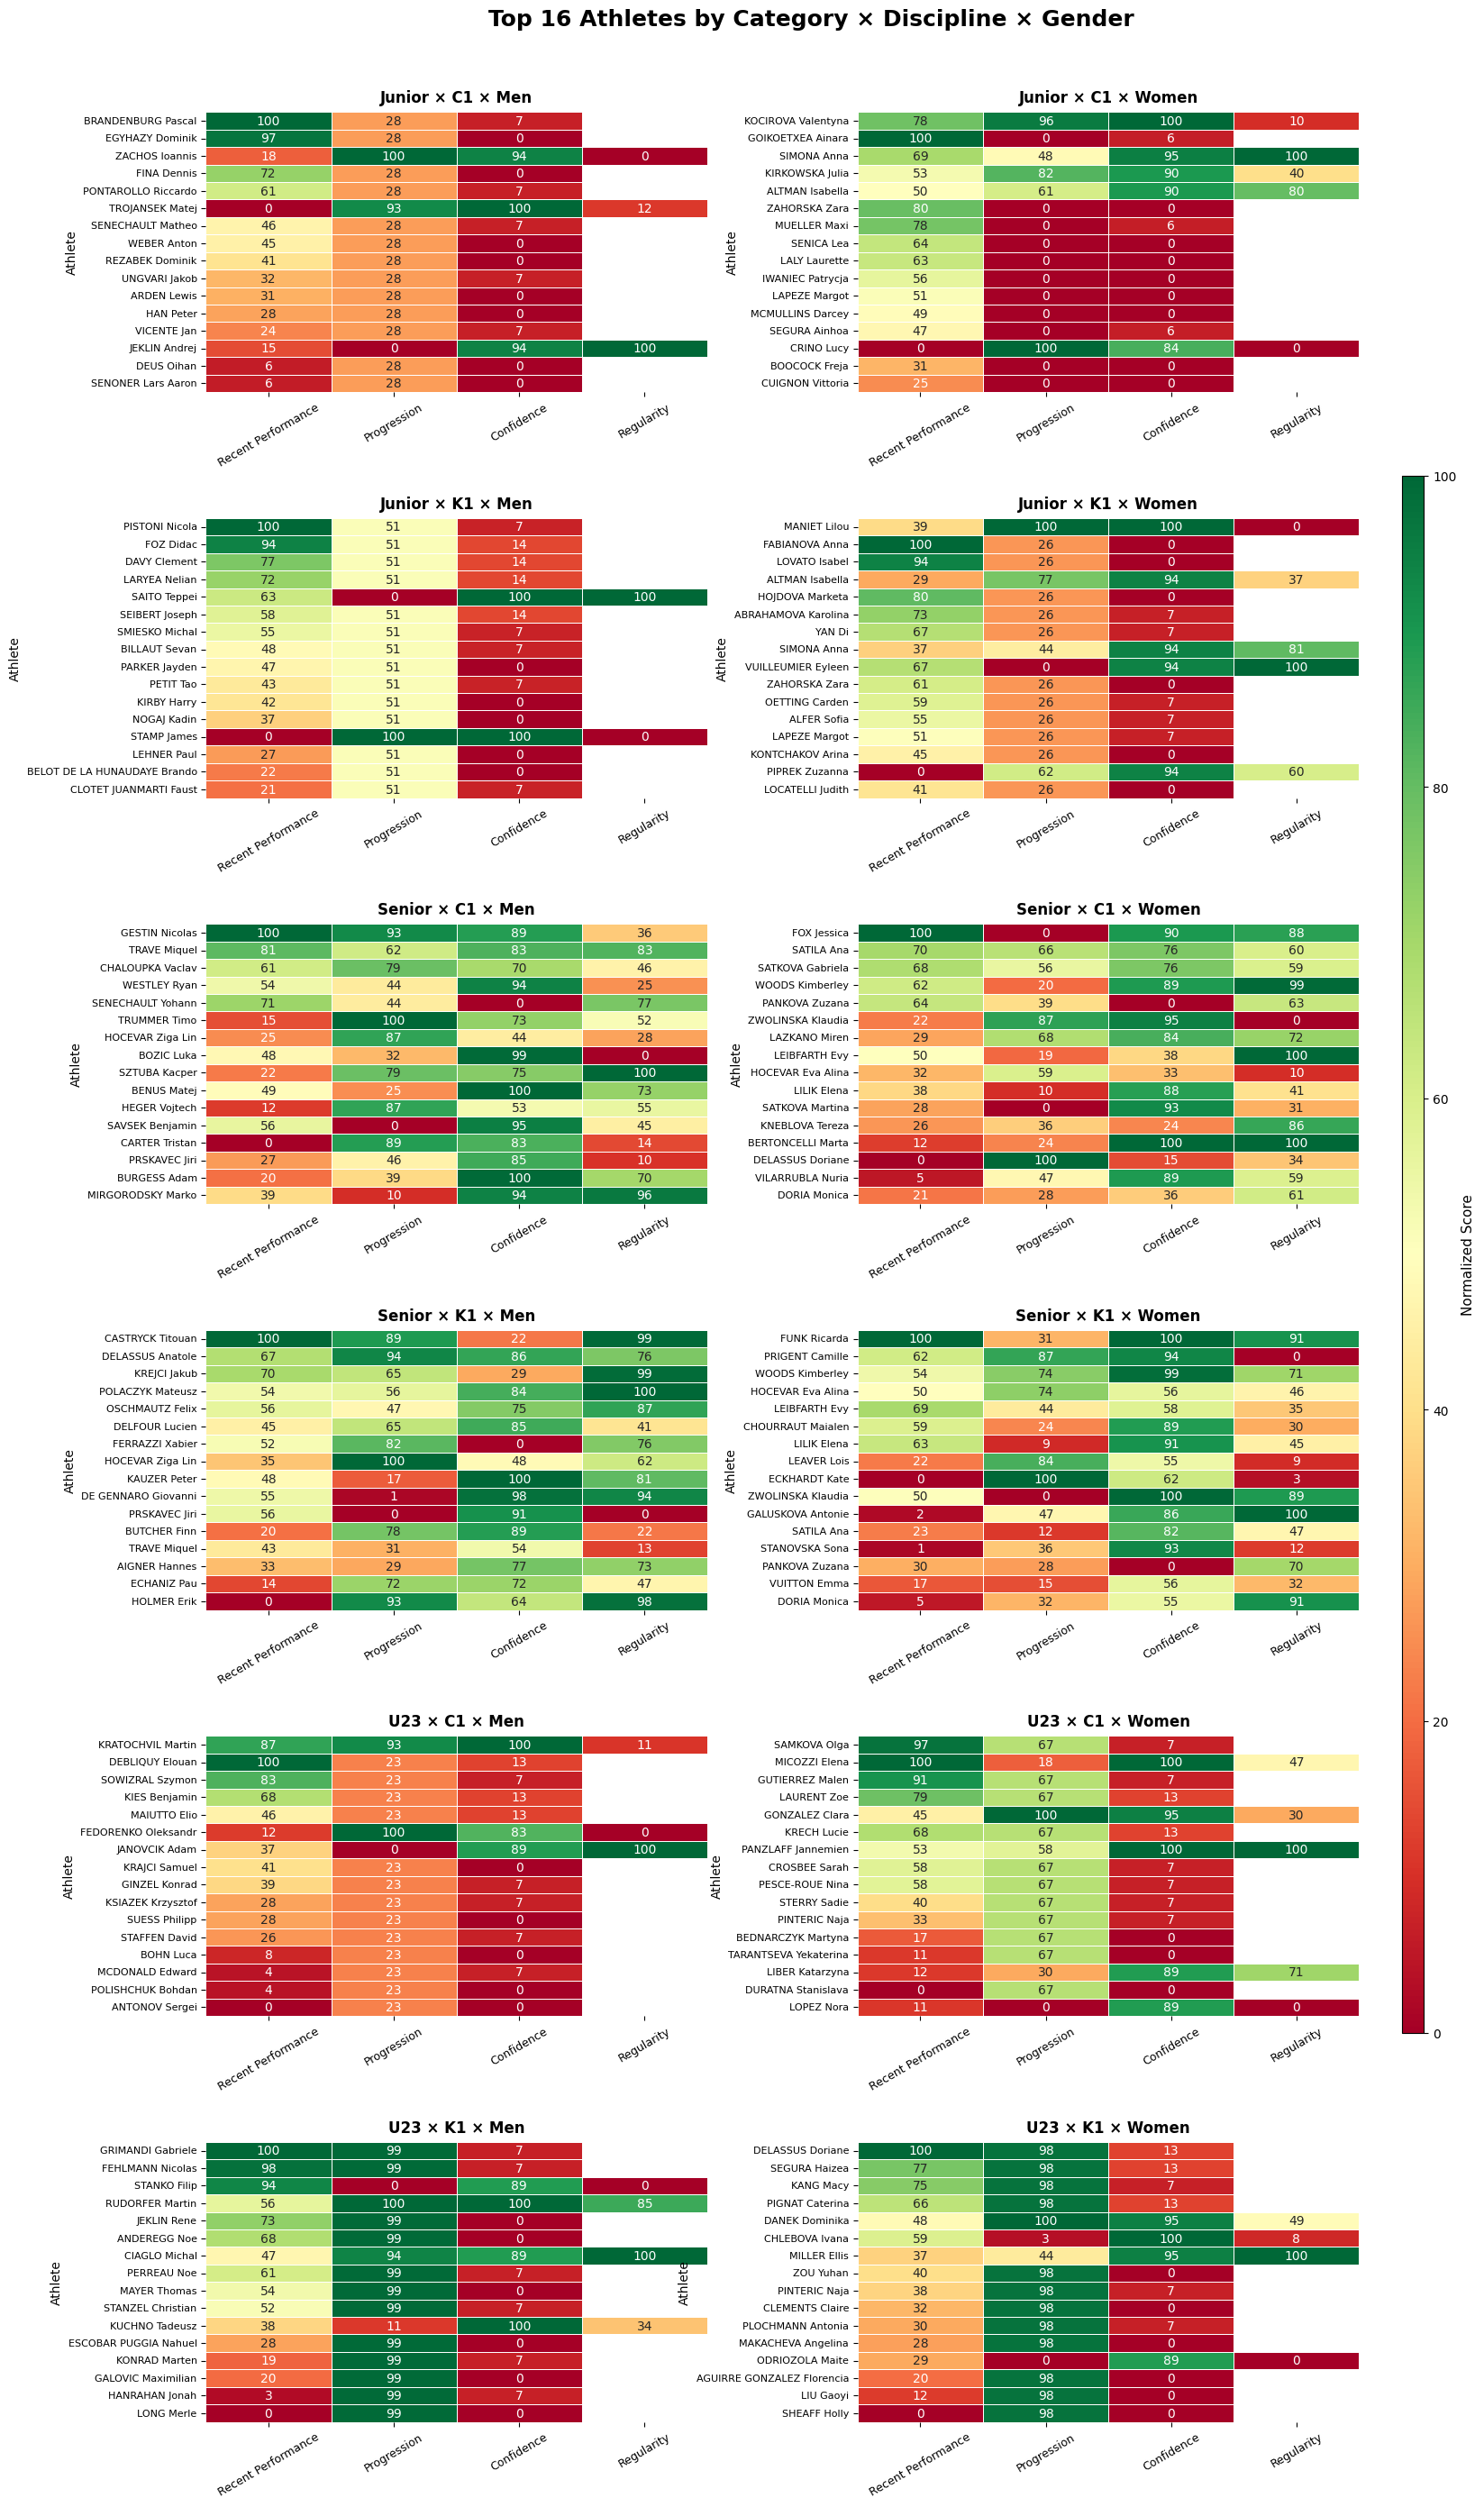

In [144]:
heatmap_cols = [
    "recency_performance",
    "progression_score",
    "confidence_score",
    "regularity_score"
]

heatmap_labels = {
    "recency_performance": "Recent Performance",
    "progression_score": "Progression",
    "confidence_score": "Confidence",
    "regularity_score": "Regularity"
}

# ============================================
# Parameters
# ============================================

TOP_N = 16

# ============================================
# Group by category × discipline × gender
# ============================================

groups = ranking.groupby(
    ["category", "discipline", "gender"]
)

n_groups = len(groups)

n_cols = 2
n_rows = (n_groups + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4.8 * n_rows),
    squeeze=False
)

axes = axes.flatten()

# ============================================
# Create one heatmap for each group
# ============================================

for ax, ((category, discipline, gender), subset) in zip(
    axes,
    groups
):

    # ----------------------------------------
    # Keep the Top 16 athletes based on rank_global
    # ----------------------------------------

    subset = (
        subset
        .sort_values("rank_global")
        .head(TOP_N)
        .copy()
    )

    # ----------------------------------------
    # Prepare heatmap data
    # ----------------------------------------

    heatmap = subset[
        ["ReportingName"] + heatmap_cols
    ].copy()

    heatmap = heatmap.set_index("ReportingName")

    # ----------------------------------------
    # Normalize scores to a 0–100 scale
    # ----------------------------------------

    for col in heatmap_cols:

        min_val = heatmap[col].min()
        max_val = heatmap[col].max()

        if max_val != min_val:
            heatmap[col] = (
                (heatmap[col] - min_val)
                / (max_val - min_val)
                * 100
            )
        else:
            heatmap[col] = 100

    # ----------------------------------------
    # Sort athletes by global rank
    # ----------------------------------------

    heatmap = heatmap.loc[
        subset["ReportingName"]
    ]

    heatmap = heatmap.rename(
        columns=heatmap_labels
    )

    # ----------------------------------------
    # Create heatmap
    # ----------------------------------------

    sns.heatmap(
        heatmap,
        cmap="RdYlGn",
        annot=True,
        fmt=".0f",
        linewidths=0.5,
        vmin=0,
        vmax=100,
        cbar=False,
        ax=ax
    )

    ax.set_title(
        f"{category} × {discipline} × {gender}",
        fontsize=12,
        fontweight="bold",
        pad=8
    )

    ax.set_xlabel("")
    ax.set_ylabel("Athlete")

    ax.tick_params(
        axis="x",
        rotation=30,
        labelsize=9
    )

    ax.tick_params(
        axis="y",
        labelsize=8
    )

# ============================================
# Remove unused axes
# ============================================

for ax in axes[n_groups:]:
    ax.remove()

# ============================================
# Add colorbar on the right
# ============================================

sm = plt.cm.ScalarMappable(
    cmap="RdYlGn",
    norm=plt.Normalize(0, 100)
)

sm.set_array([])

# Explicitly reserve space on the right for the colorbar
fig.subplots_adjust(
    left=0.08,
    right=0.88,
    top=0.94,
    bottom=0.05,
    wspace=0.30,
    hspace=0.45
)

# Manually define the colorbar position
cbar_ax = fig.add_axes([
    0.91,   # left
    0.20,   # bottom
    0.015,  # width
    0.60    # height
])

cbar = fig.colorbar(
    sm,
    cax=cbar_ax
)

cbar.set_label(
    "Normalized Score",
    fontsize=11
)

# ============================================
# Global title
# ============================================

fig.suptitle(
    f"Top {TOP_N} Athletes by Category × Discipline × Gender",
    fontsize=18,
    fontweight="bold"
)

plt.show()